# Analisis de Conversion -- The Box (OLA y Montana S.A.C.)
## Trabajo Final de Ingenieria Empresarial -- TFIE 26-2

**Objetivo:** Diagnosticar la baja conversion de visitantes en compradores, cuantificar la brecha
respecto a un referente interno y encontrar evidencia que oriente mejoras.

**Fuente unica:** `BD The Box Presentacion 30.08.xlsx`

*Nota: los valores comentados en `the_box_analisis.R` son referencias para contrastar,
no resultados verificados. Todo calculo parte del Excel.*

**Periodo:** Semanas 1-52 de 2025 y 1-34 (+semana 35 incompleta) de 2026. **Tiendas:** 16 locales THE BOX en Peru.

## Bloque 0 · Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import display
from linearmodels.panel import PanelOLS
from scipy import stats

try:
    REPO = Path(__file__).parent
except NameError:
    REPO = Path().resolve()

DATOS = REPO / 'BD The Box Presentacion 30.08.xlsx'
FIG   = REPO / 'outputs' / 'figuras'
TAB   = REPO / 'outputs' / 'tablas'
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 150, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titlesize': 11, 'axes.labelsize': 10})
sns.set_palette('tab10')

COLS_RAW = ['anio','semana','fecha','inicio_semana','hora','categoria',
            'nro_tienda','tienda','nombre_tienda','flujo','transacciones','venta','unidades']
DAY_NAMES = {1:'Lun', 2:'Mar', 3:'Mie', 4:'Jue', 5:'Vie', 6:'Sab', 7:'Dom'}
R = {}  # acumula resultados para el markdown

def savefig(name):
    plt.savefig(FIG / name, bbox_inches='tight', dpi=150)
    plt.show(); plt.close()

def weighted_frontier(sw, p):
    q = (sw.groupby('nombre_tienda')
           .apply(lambda g: pd.Series({'q': g['conv'].quantile(p), 'w': g['f'].sum()}))
           .reset_index())
    return float((q['q'] * q['w']).sum() / q['w'].sum())

def dual_bar_line(df, xcol, barcol, linecol, title, xlabel, ylabel_bar, ylabel_line, fname, xlabels=None):
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
    ax1.bar(df[xcol], df[barcol], color='#9ecae1', alpha=0.85)
    ax2.plot(df[xcol], df[linecol], color='#d62728', marker='o', linewidth=2)
    ax1.set_title(title); ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabel_bar); ax2.set_ylabel(ylabel_line)
    ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    if xlabels is not None:
        ax1.set_xticks(df[xcol]); ax1.set_xticklabels(xlabels)
    savefig(fname)

print('Setup OK -- REPO:', REPO)


Setup OK -- REPO: C:\Users\ADMIN\Desktop\UP\TRABAJO FINAL INGENIERÍA EMPRESARIAL\TFIE_26_2


## Bloque 1 · Objetivo, alcance y diccionario de datos

**Conversion** = Transacciones / Flujo (fraccion de visitantes que compran).

### Diccionario -- Hoja `BD Venta por hora`

| Variable | Tipo | Descripcion |
|---|---|---|
| `anio` | int | Ano fiscal (2025 o 2026) |
| `semana` | int | Semana ISO (1-52) |
| `hora` | int | Hora del dia (8-22) |
| `nombre_tienda` | str | Nombre del local |
| `flujo` | int | Visitantes por sensor |
| `transacciones` | int | Boletas emitidas |
| `venta` | float | Venta en S/ |
| `unidades` | int | Unidades vendidas |

### Muestras utilizadas

| Nombre | Definicion |
|---|---|
| `raw` | Todo THE BOX sin filtro |
| `dep` | hora 10-21, flujo>0, flujo>=trx, **semana!=35** |
| `sw26/sw25` | dep + sem 2-34 + f>=100 + t>=10 por tienda-semana |
| `comunes` | Tiendas en dep de 2025 Y 2026, sem 2-34 |

> **Semana 35 excluida:** solo cubre 2026-08-24 (1 dia, flujo=156). Se excluye de `dep`.

In [2]:
raw = pd.read_excel(DATOS, sheet_name='BD Venta por hora', usecols=list(range(13)))
raw.columns = COLS_RAW
raw['fecha'] = pd.to_datetime(raw['fecha'])
for col in ['anio','semana','hora','flujo','transacciones','venta','unidades']:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

tb = raw[raw['categoria'].eq('THE BOX')].copy()
mask = (tb['hora'].between(10,21) & tb['flujo'].gt(0)
        & tb['flujo'].ge(tb['transacciones']) & tb['semana'].ne(35))
dep = tb[mask].copy()

print(f'raw:       {len(raw):,}  (esperado: 122 329)')
print(f'THE BOX:   {len(tb):,}  (esperado: 103 790)')
print(f'dep:       {len(dep):,}')
print(f'Tiendas:   {tb["nombre_tienda"].nunique()}')
print(f'Semanas 2026: {sorted(dep[dep["anio"]==2026]["semana"].unique())}')
display(dep.dtypes.rename('dtype').to_frame())
R['n_raw'] = len(raw); R['n_tb'] = len(tb); R['n_dep'] = len(dep)


raw:       122,329  (esperado: 122 329)
THE BOX:   103,790  (esperado: 103 790)
dep:       96,730
Tiendas:   16
Semanas 2026: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34)]


,dtype
anio,int64
semana,int64
fecha,datetime64[ns]
inicio_semana,datetime64[ns]
hora,int64
categoria,object
nro_tienda,int64
tienda,object
nombre_tienda,object
flujo,int64


## Bloque 2 · Calidad de datos y depuracion

**Pregunta:** Que proporcion de registros presenta inconsistencias y cuanto afectan a la conversion reportada?

> Las reglas de depuracion pueden solaparse. Se muestran tanto por separado como en union.

In [3]:
calidad = tb.groupby('anio').apply(lambda g: pd.Series({
    'filas':             len(g),
    'flujo_total':       g['flujo'].sum(),
    'trx_total':         g['transacciones'].sum(),
    'conv_reportada':    g['transacciones'].sum() / g['flujo'].sum(),
    'filas_flujo_cero':  int((g['flujo']==0).sum()),
    'trx_en_flujo_cero': g.loc[g['flujo']==0,'transacciones'].sum(),
    'pct_trx_flujo_cero':g.loc[g['flujo']==0,'transacciones'].sum() / g['transacciones'].sum(),
    'flujo_hora22':      g.loc[g['hora']==22,'flujo'].sum(),
    'trx_hora22':        g.loc[g['hora']==22,'transacciones'].sum(),
})).reset_index()
print('--- Calidad por ano (raw THE BOX) ---')
print(calidad.to_string(index=False))
print('\nRef R (comentario, no verificada): 2026 conv=0.06815, 2025 conv=0.06468')
calidad.to_csv(TAB / 'calidad_datos.csv', index=False)
R['calidad'] = calidad.copy()


--- Calidad por ano (raw THE BOX) ---
 anio   filas  flujo_total  trx_total  conv_reportada  filas_flujo_cero  trx_en_flujo_cero  pct_trx_flujo_cero  flujo_hora22  trx_hora22
 2025 59800.0    1339121.0    86615.0        0.064680            3335.0             6156.0            0.071073         143.0      2082.0
 2026 43990.0     951049.0    64811.0        0.068147            1753.0             3135.0            0.048371          25.0      1532.0

Ref R (comentario, no verificada): 2026 conv=0.06815, 2025 conv=0.06468


In [4]:
# Exclusiones por regla (no se suman: pueden solaparse)
r_hor   = ~tb['hora'].between(10,21)
r_f0    = tb['flujo'].le(0)
r_inc   = tb['flujo'].lt(tb['transacciones'])
r_s35   = tb['semana'].eq(35)
r_union = r_hor | r_f0 | r_inc | r_s35

def rsum(mask, label):
    sub = tb[mask]
    return {'Regla': label, 'Filas': len(sub),
            'Flujo': int(sub['flujo'].sum()),
            'Transacciones': int(sub['transacciones'].sum()),
            'Venta_S/': round(sub['venta'].sum(), 0)}

excl_df = pd.DataFrame([
    rsum(r_hor,   'Fuera de horario 10-21h'),
    rsum(r_f0,    'Flujo = 0 o negativo'),
    rsum(r_inc,   'Flujo < Transacciones'),
    rsum(r_s35,   'Semana 35 incompleta (1 dia)'),
    rsum(r_union, 'Excluidas totales (union)'),
    rsum(~r_union,'MUESTRA DEPURADA (dep)'),
])
print('--- Exclusiones por regla ---')
print(excl_df.to_string(index=False))
excl_df.to_csv(TAB / 'exclusiones_depuracion.csv', index=False)

dup = dep.duplicated(subset=['nombre_tienda','fecha','hora'])
print(f'\nDuplicados tienda-fecha-hora en dep: {dup.sum()}')
for col in ['flujo','transacciones','venta','unidades']:
    print(f'  {col} negativos: {(dep[col]<0).sum()}')

# Conversion depurada sem 2-34
conv_dep_234 = dep[dep['semana'].between(2,34)].groupby('anio').apply(
    lambda g: g['transacciones'].sum()/g['flujo'].sum()).reset_index(name='conv_dep_sem234')
print('\n--- Conversion dep, sem 2-34 ---')
print(conv_dep_234.to_string(index=False))
print('Esperado desde Excel: 2025=5.5610%, 2026=6.4815%')
conv_dep_234.to_csv(TAB / 'conversion_dep_sem234.csv', index=False)
R['conv_dep_234'] = conv_dep_234.copy()


--- Exclusiones por regla ---
                       Regla  Filas   Flujo  Transacciones   Venta_S/
     Fuera de horario 10-21h   2828    1648           3901  1356841.0
        Flujo = 0 o negativo   5088       0           9291  2915895.0
       Flujo < Transacciones   5299     406          10054  3126655.0
Semana 35 incompleta (1 dia)   1162   23442           1528   512895.0
   Excluidas totales (union)   7060   25484          11513  3620154.0
      MUESTRA DEPURADA (dep)  96730 2264686         139913 45329287.0

Duplicados tienda-fecha-hora en dep: 0
  flujo negativos: 0
  transacciones negativos: 0
  venta negativos: 0
  unidades negativos: 0

--- Conversion dep, sem 2-34 ---
 anio  conv_dep_sem234
 2025         0.055610
 2026         0.064815
Esperado desde Excel: 2025=5.5610%, 2026=6.4815%


In [5]:
# Cobertura de tiendas y desglose de exclusiones por tienda
excl_x_tienda = tb[r_union].groupby('nombre_tienda').agg(
    excluidas=('flujo','count'), flujo=('flujo','sum'), trx=('transacciones','sum')
).reset_index().sort_values('excluidas', ascending=False)
print('--- Exclusiones por tienda (union de reglas) ---')
print(excl_x_tienda.to_string(index=False))
excl_x_tienda.to_csv(TAB / 'exclusiones_por_tienda.csv', index=False)

cob = dep[dep['semana'].between(2,34)].groupby(['nombre_tienda','anio']).agg(
    semanas=('semana','nunique'), flujo=('flujo','sum')).unstack('anio').reset_index()
cob.columns = ['nombre_tienda','sem_2025','sem_2026','flujo_2025','flujo_2026']
cob = cob.fillna(0)
print('\n--- Cobertura de semanas por tienda (sem 2-34) ---')
print(cob.to_string(index=False))
cob.to_csv(TAB / 'cobertura_tiendas.csv', index=False)


--- Exclusiones por tienda (union de reglas) ---
                            nombre_tienda  excluidas  flujo  trx
              THE BOX MEGA PLAZA CHIMBOTE       1658    547 2899
                 THE BOX REAL PLAZA CUSCO        844   2361  259
                       THE BOX SAN ISIDRO        715   1051 1349
              THE BOX MALL PLAZA TRUJILLO        601   4047 1383
                     THE BOX JOCKEY PLAZA        396   4140 1073
           THE BOX MALL AVENTURA CHICLAYO        368   1961  656
        THE BOX MALL AVENTURA SANTA ANITA        349    922  538
           THE BOX REAL PLAZA PURUCHUCO 1        305   1564  472
              THE BOX LA RAMBLA SAN BORJA        295   1608  443
         THE BOX MEGA PLAZA INDEPENDENCIA        282   2398  481
        THE BOX MALL PLAZA AREQUIPA CAYMA        248    950  346
            THE BOX REAL PLAZA CHICLAYO 1        245   1772  364
               THE BOX REAL PLAZA PIURA 2        236      8  481
THE BOX MALL AVENTURA AREQUIPA PORONGOCHE

## Bloque 3 · Evolucion 2025-2026 (semanas 2-34)

**Pregunta:** Cuanto crecio la venta y que componentes lo explican?

**Metodo:** Descomposicion logaritmica de venta = flujo x conversion x ticket (descomposicion **contable identitaria, no causal**).

**Nota de comparabilidad:**
- *Total cadena:* dep, sem 2-34. En 2025 habia 14 tiendas; en 2026, 16 (nuevas: LARCOMAR 2 y REAL PLAZA PIURA 2). **Comparacion no homogenea.**
- *Tiendas comunes (14):* presente en dep de ambos anos. Es la comparacion mas valida.

**Discrepancia con script R:**
Los comentarios del script R tienen +94.1% (total) y +75.9% (comunes). Esos son valores escritos como referencia en el codigo, **no resultados verificados de ejecucion**. Los valores calculados aqui desde el Excel son los reportados. La diferencia en total se explica en parte por el mix distinto de tiendas. La diferencia en tiendas comunes **queda pendiente de verificacion ejecutando R**.

In [6]:
comp_total = dep[dep['semana'].between(2,34)].groupby('anio').agg(
    flujo=('flujo','sum'), trx=('transacciones','sum'),
    venta=('venta','sum'), unid=('unidades','sum'),
    tiendas=('nombre_tienda','nunique')).reset_index()
comp_total['conv']   = comp_total['trx']   / comp_total['flujo']
comp_total['ticket'] = comp_total['venta'] / comp_total['trx']
comp_total['upt']    = comp_total['unid']  / comp_total['trx']
display(comp_total[['anio','tiendas','flujo','trx','venta','conv','ticket']])

a25 = comp_total[comp_total['anio']==2025].iloc[0]
a26 = comp_total[comp_total['anio']==2026].iloc[0]
dlv = np.log(a26['venta']/a25['venta'])
crec_total = a26['venta']/a25['venta'] - 1
ap_flujo   = np.log(a26['flujo']  /a25['flujo'])  / dlv
ap_conv    = np.log(a26['conv']   /a25['conv'])   / dlv
ap_ticket  = np.log(a26['ticket'] /a25['ticket']) / dlv

print(f'Crecimiento venta total cadena: {crec_total:+.1%}  (mix distinto: 14 vs 16 tiendas)')
print(f'  Aporte flujo:      {ap_flujo:+.1%}  (contable)')
print(f'  Aporte conversion: {ap_conv:+.1%}  (contable)')
print(f'  Aporte ticket:     {ap_ticket:+.1%}  (contable)')
print(f'  Ref R (comentario, no verificada): +94.1%, 35.9%, 16.5%, 47.5%')
comp_total.to_csv(TAB / 'comparacion_total_cadena.csv', index=False)
R['comp_total']=comp_total.copy(); R['crec_total']=crec_total
R['ap_flujo']=ap_flujo; R['ap_conv']=ap_conv; R['ap_ticket']=ap_ticket


,anio,tiendas,flujo,trx,venta,conv,ticket
0,2025,14,703705,39133,1.014057e+07,0.055610,259.130818
1,2026,16,893219,57894,2.054669e+07,0.064815,354.901853


Crecimiento venta total cadena: +102.6%  (mix distinto: 14 vs 16 tiendas)
  Aporte flujo:      +33.8%  (contable)
  Aporte conversion: +21.7%  (contable)
  Aporte ticket:     +44.5%  (contable)
  Ref R (comentario, no verificada): +94.1%, 35.9%, 16.5%, 47.5%


In [7]:
t25 = set(dep[(dep['anio']==2025)&dep['semana'].between(2,34)]['nombre_tienda'])
t26 = set(dep[(dep['anio']==2026)&dep['semana'].between(2,34)]['nombre_tienda'])
comunes = sorted(t25 & t26)
print(f'Tiendas comunes: {len(comunes)}')
print(f'Solo en 2026 (nuevas): {sorted(t26-t25)}')

comp_com = dep[dep['semana'].between(2,34) & dep['nombre_tienda'].isin(comunes)].groupby('anio').agg(
    flujo=('flujo','sum'), trx=('transacciones','sum'), venta=('venta','sum')).reset_index()
comp_com['conv']   = comp_com['trx']  / comp_com['flujo']
comp_com['ticket'] = comp_com['venta']/ comp_com['trx']
crec_com = comp_com[comp_com['anio']==2026]['venta'].values[0] / comp_com[comp_com['anio']==2025]['venta'].values[0] - 1
print(f'Crecimiento tiendas comunes: {crec_com:+.1%}  (ref R comentario: +75.9% -- pendiente verificacion)')
display(comp_com[['anio','flujo','trx','venta','conv','ticket']])
comp_com.to_csv(TAB / 'comparacion_tiendas_comunes.csv', index=False)
R['crec_com']=crec_com; R['comp_com']=comp_com.copy(); R['comunes']=comunes

# Cobertura comparable de semanas en tiendas comunes
cob_com = dep[dep['semana'].between(2,34) & dep['nombre_tienda'].isin(comunes)]    .groupby(['nombre_tienda','anio']).agg(semanas=('semana','nunique')).unstack('anio').reset_index()
cob_com.columns = ['nombre_tienda','sem_2025','sem_2026']
print('\nSemanas activas por tienda comun:')
print(cob_com.to_string(index=False))


Tiendas comunes: 14
Solo en 2026 (nuevas): ['THE BOX LARCOMAR 2', 'THE BOX REAL PLAZA PIURA 2']
Crecimiento tiendas comunes: +85.2%  (ref R comentario: +75.9% -- pendiente verificacion)


,anio,flujo,trx,venta,conv,ticket
0,2025,703705,39133,1.014057e+07,0.055610,259.130818
1,2026,813425,53250,1.878053e+07,0.065464,352.686029



Semanas activas por tienda comun:
                            nombre_tienda  sem_2025  sem_2026
                     THE BOX JOCKEY PLAZA        33        33
                 THE BOX LA RAMBLA BRASIL        33        33
              THE BOX LA RAMBLA SAN BORJA        33        33
THE BOX MALL AVENTURA AREQUIPA PORONGOCHE        33        33
           THE BOX MALL AVENTURA CHICLAYO        33        33
        THE BOX MALL AVENTURA SANTA ANITA        33        33
        THE BOX MALL PLAZA AREQUIPA CAYMA        33        33
              THE BOX MALL PLAZA TRUJILLO        33        33
              THE BOX MEGA PLAZA CHIMBOTE        33        29
         THE BOX MEGA PLAZA INDEPENDENCIA        33        33
            THE BOX REAL PLAZA CHICLAYO 1        33        33
                 THE BOX REAL PLAZA CUSCO        33        33
           THE BOX REAL PLAZA PURUCHUCO 1        33        33
                       THE BOX SAN ISIDRO        28        33


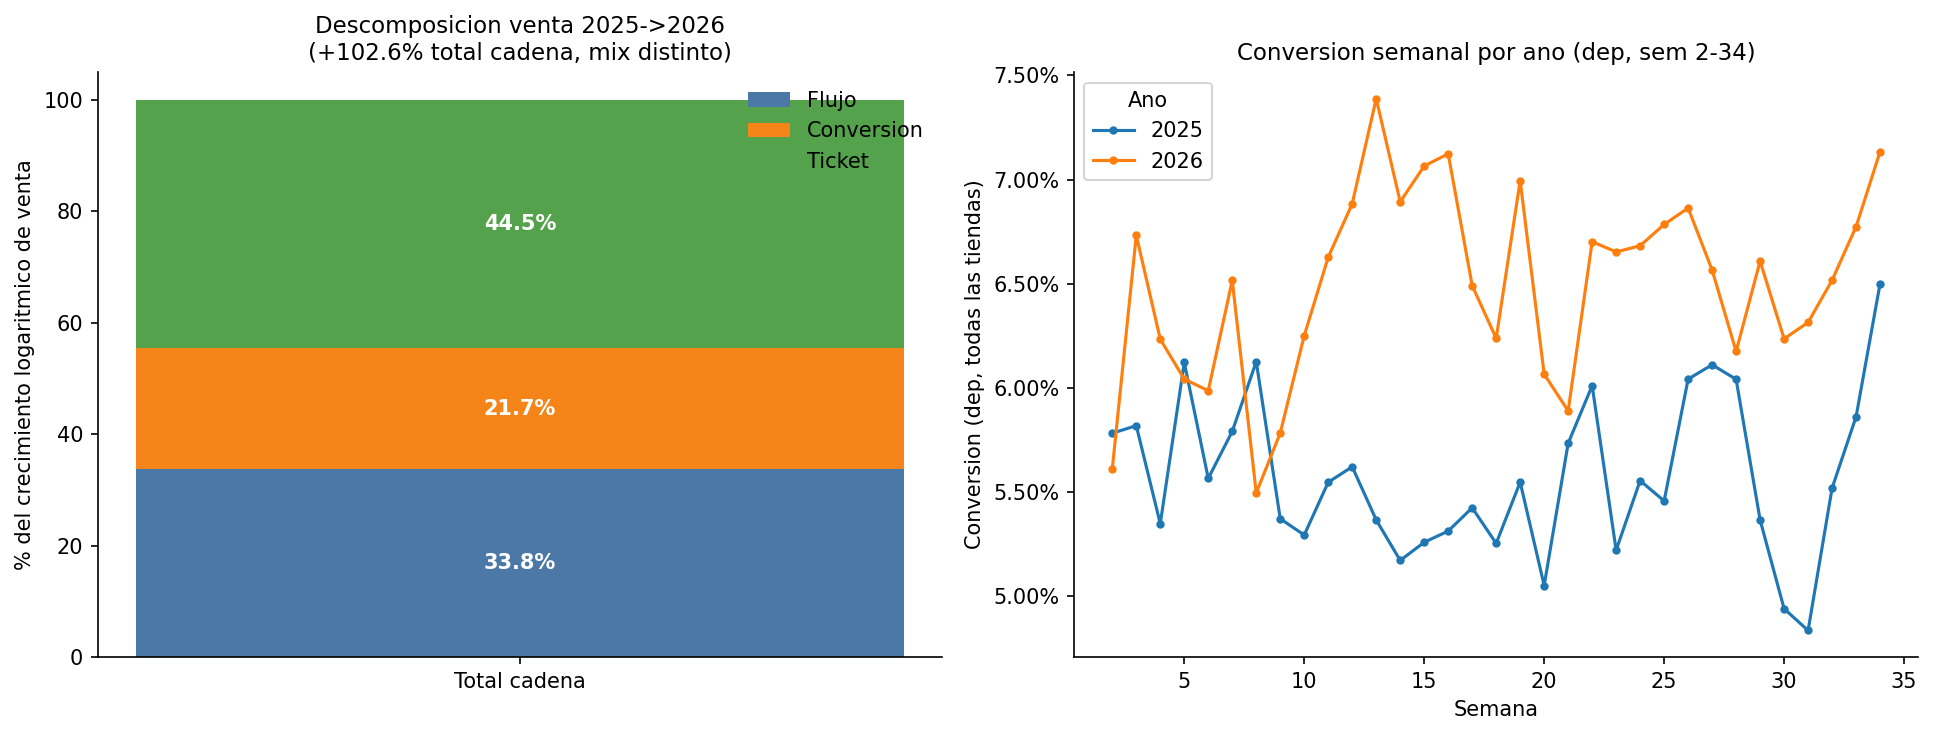

In [8]:
fig, axes = plt.subplots(1,2, figsize=(13,5))

# Descomposicion
ax = axes[0]
aportes = [ap_flujo*100, ap_conv*100, ap_ticket*100]
labels  = ['Flujo','Conversion','Ticket']
colors  = ['#4C78A8','#F58518','#54A24B']
bottom  = 0
for lbl, val, col in zip(labels, aportes, colors):
    ax.bar(['Total cadena'], val, bottom=bottom, color=col, label=lbl)
    ax.text(0, bottom+val/2, f'{val:.1f}%', ha='center', va='center', color='white', fontweight='bold')
    bottom += val
ax.set_ylabel('% del crecimiento logaritmico de venta')
ax.set_title(f'Descomposicion venta 2025->2026\n({crec_total:+.1%} total cadena, mix distinto)')
ax.legend(frameon=False)

# Conversion semanal
ax2 = axes[1]
cs = dep[dep['semana'].between(2,34)].groupby(['anio','semana']).apply(
    lambda g: g['transacciones'].sum()/g['flujo'].sum()).reset_index(name='conv')
for anio, grp in cs.groupby('anio'):
    ax2.plot(grp['semana'], grp['conv'], marker='o', ms=3, lw=1.5, label=str(int(anio)))
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.set_xlabel('Semana'); ax2.set_ylabel('Conversion (dep, todas las tiendas)')
ax2.set_title('Conversion semanal por ano (dep, sem 2-34)')
ax2.legend(title='Ano')
plt.tight_layout()
savefig('evolucion_descomposicion.png')


## Bloque 4 · Conversion real y referencia interna (frontera)

**Conversion de referencia (dep, sem 2-34):** 2025=5.5610%, 2026=6.4815%

**sw26:** tienda x semana 2026, sem 2-34, f>=100 y t>=10. La conversion agregada de sw26 (6.4823%) es practicamente igual a dep (6.4815%); los filtros de minimo excluyen pocas observaciones.

> El p90 ponderado es **referencia interna de desempeno observado** -- no una meta sostenible garantizada. Representa lo que esa tienda ya logro en sus mejores semanas.

In [9]:
def make_sw(anio, sem_min=2, sem_max=34, min_f=100, min_t=10):
    sw = dep[(dep['anio']==anio) & dep['semana'].between(sem_min,sem_max)]        .groupby(['nombre_tienda','semana'])        .agg(f=('flujo','sum'), t=('transacciones','sum'), v=('venta','sum'), u=('unidades','sum'))        .reset_index()
    sw = sw[(sw['f']>=min_f) & (sw['t']>=min_t)].copy()
    sw['conv'] = sw['t'] / sw['f']
    return sw

sw26 = make_sw(2026)
sw25 = make_sw(2025)
conv_real_26 = sw26['t'].sum() / sw26['f'].sum()
conv_real_25 = sw25['t'].sum() / sw25['f'].sum()
print(f'conv_real sw26: {conv_real_26*100:.4f}%  (dep sem2-34: 6.4815%)')
print(f'conv_real sw25: {conv_real_25*100:.4f}%  (dep sem2-34: 5.5610%)')

res_f = []
for p in [0.75, 0.90, 1.00]:
    v = weighted_frontier(sw26, p)
    res_f.append({'percentil': f'p{int(p*100)}', 'frontera_%': round(v*100,4),
                  'brecha_pp': round((v-conv_real_26)*100, 4)})
    print(f'  p{int(p*100):3d} = {v*100:.4f}%  brecha = {(v-conv_real_26)*100:.4f} pp')
print('Ref R (verificada por replica exacta): p75=7.1980%, p90=7.7848%, max=8.5843%')
frontera_agg = pd.DataFrame(res_f)
frontera_agg.to_csv(TAB / 'frontera_agregada.csv', index=False)
R['conv_real_26']=conv_real_26; R['frontera_agg']=frontera_agg.copy()


conv_real sw26: 6.4823%  (dep sem2-34: 6.4815%)
conv_real sw25: 5.5609%  (dep sem2-34: 5.5610%)
  p 75 = 7.1980%  brecha = 0.7157 pp
  p 90 = 7.7848%  brecha = 1.3025 pp
  p100 = 8.5843%  brecha = 2.1020 pp
Ref R (verificada por replica exacta): p75=7.1980%, p90=7.7848%, max=8.5843%


,nombre_tienda,semanas_val,conv_real_%,p90_%,brecha_p90_pp
0,THE BOX REAL PLAZA CUSCO,33.0,8.577938,10.555689,1.977751
1,THE BOX REAL PLAZA PURUCHUCO 1,33.0,7.607060,8.881123,1.274063
2,THE BOX MALL PLAZA AREQUIPA CAYMA,33.0,7.559546,8.986704,1.427158
3,THE BOX SAN ISIDRO,33.0,7.422139,13.393939,5.971800
4,THE BOX MALL AVENTURA SANTA ANITA,33.0,7.400929,8.513465,1.112536
5,THE BOX MALL AVENTURA AREQUIPA PORONGOCHE,33.0,7.096959,8.646583,1.549624
6,THE BOX MALL AVENTURA CHICLAYO,33.0,6.971071,8.174438,1.203367
7,THE BOX LA RAMBLA SAN BORJA,33.0,6.957521,8.709185,1.751664
8,THE BOX LA RAMBLA BRASIL,33.0,6.540314,8.032701,1.492388
9,THE BOX JOCKEY PLAZA,33.0,6.443544,6.951466,0.507922


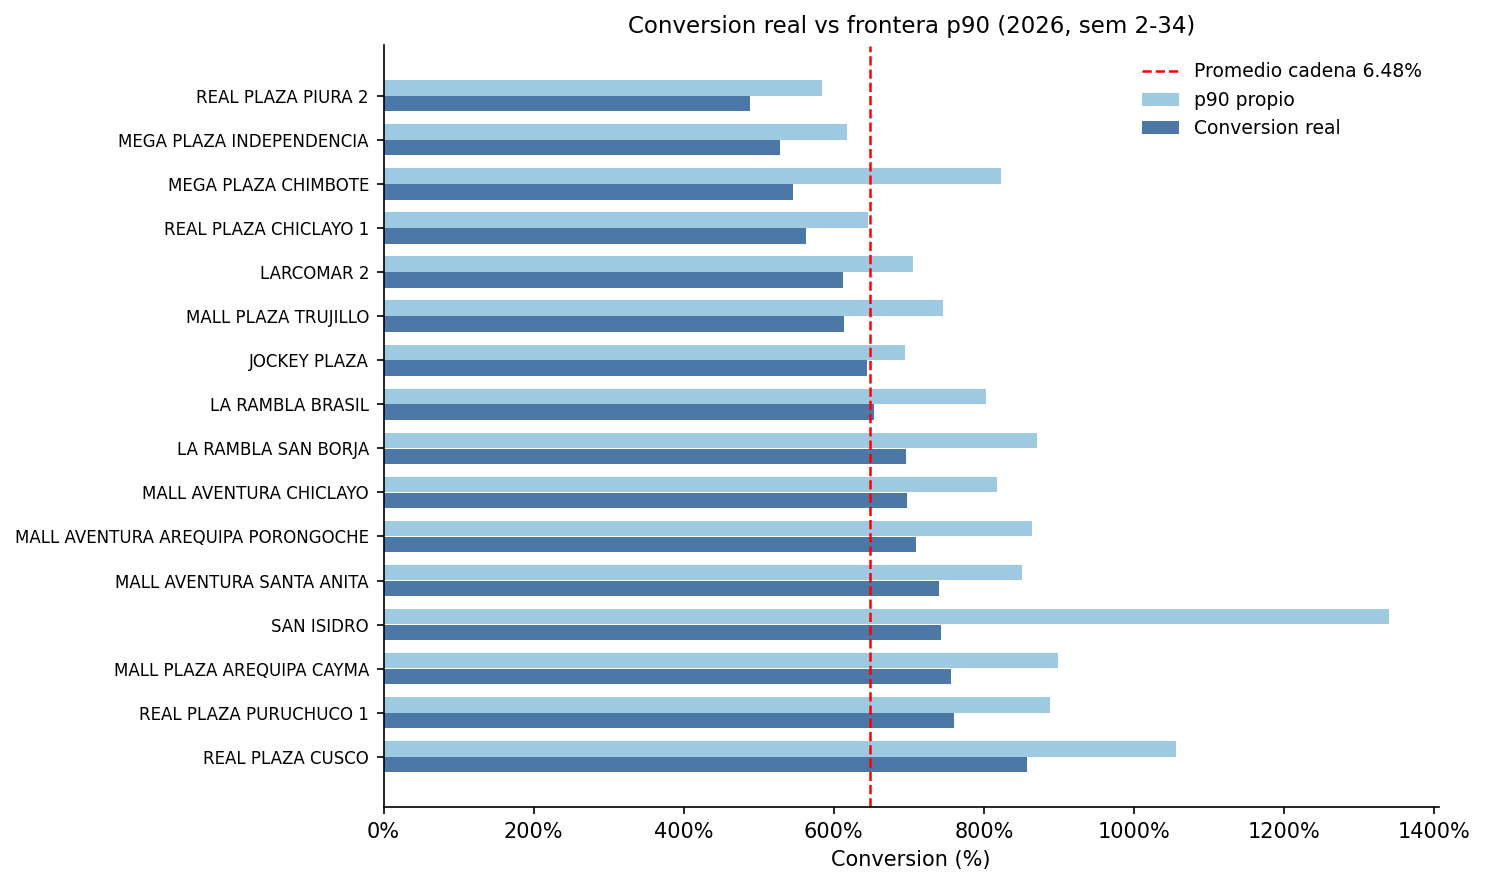

In [10]:
ft = sw26.groupby('nombre_tienda').apply(lambda g: pd.Series({
    'flujo_total':   g['f'].sum(), 'semanas_val': len(g),
    'conv_real_%':   g['t'].sum()/g['f'].sum()*100,
    'p75_%':         g['conv'].quantile(0.75)*100,
    'p90_%':         g['conv'].quantile(0.90)*100,
    'max_%':         g['conv'].max()*100,
})).reset_index()
ft['brecha_p90_pp'] = ft['p90_%'] - ft['conv_real_%']
ft = ft.sort_values('conv_real_%', ascending=False).reset_index(drop=True)
display(ft[['nombre_tienda','semanas_val','conv_real_%','p90_%','brecha_p90_pp']])
ft.to_csv(TAB / 'frontera_por_tienda.csv', index=False)
R['ft'] = ft.copy()

fig, ax = plt.subplots(figsize=(10,6))
y = np.arange(len(ft))
ax.barh(y+0.18, ft['p90_%'], height=0.35, color='#9ecae1', label='p90 propio')
ax.barh(y-0.18, ft['conv_real_%'], height=0.35, color='#4C78A8', label='Conversion real')
ax.set_yticks(y); ax.set_yticklabels(ft['nombre_tienda'].str.replace('THE BOX ','',regex=False), fontsize=8)
ax.axvline(conv_real_26*100, color='red', ls='--', lw=1.2, label=f'Promedio cadena {conv_real_26*100:.2f}%')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax.set_xlabel('Conversion (%)'); ax.set_title('Conversion real vs frontera p90 (2026, sem 2-34)')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); savefig('frontera_conversion.png')


## Bloque 5 · Relacion trafico-conversion

**Tres especificaciones:** (1) Panel hora (FE tienda_hora + fecha), (2) Panel semana (FE tienda + periodo), (3) Correlaciones entre tiendas.

**Diferencias Python vs R/fixest:** `linearmodels.PanelOLS` aplica within-transformation. Para M2, la diferencia de p-valor (Python ~0.048 vs R comentario 0.056) se debe a distinta correccion de grados de libertad en la varianza agrupada. No se ajustaron parametros para igualar el resultado.

> **Advertencia:** La relacion negativa trafico-conversion es **asociacion observacional**. NO implica causalidad, falta de personal ni ninguna causa especifica. Puede reflejar composicion de visitantes, errores de medicion del contador, o congestion real. Los efectos fijos controlan medias fijas pero no eliminan todos los confusores.

In [11]:
h = dep[dep['flujo'] >= 20].copy()
h['conv']        = h['transacciones'] / h['flujo']
h['lf']          = np.log(h['flujo'])
h['tienda_hora'] = h['nombre_tienda'] + '_' + h['hora'].astype(str)

hpanel = h.set_index(['tienda_hora','fecha']).sort_index()
hpanel = hpanel[~hpanel.index.duplicated(keep='first')]
clusters_h = pd.DataFrame({'g': pd.Categorical(hpanel['nombre_tienda']).codes}, index=hpanel.index)

m1 = PanelOLS(hpanel['conv'], hpanel[['lf']],
              entity_effects=True, time_effects=True, drop_absorbed=True)     .fit(cov_type='clustered', clusters=clusters_h)

beta1 = float(m1.params['lf'])
se1   = float(m1.std_errors['lf'])
pv1   = float(m1.pvalues['lf'])
ci1   = m1.conf_int().loc['lf'].values
n1    = int(m1.nobs)
effect10 = beta1 * np.log(1.1) * 100
pv1_str = f'{pv1:.2e}' if pv1 < 0.001 else f'{pv1:.4f}'

print(f'M1 Panel hora: n={n1:,} | beta={beta1:.5f} | SE={se1:.5f} | p={pv1_str}')
print(f'  IC95: [{ci1[0]:.5f}, {ci1[1]:.5f}]')
print(f'  +10% flujo => {effect10:.4f} pp conv  (ref R: -0.1509 pp)')
R['m1'] = {'beta':beta1,'se':se1,'pval':pv1,'n':n1,'ci':list(ci1),'effect10':effect10}


M1 Panel hora: n=38,461 | beta=-0.01585 | SE=0.00264 | p=1.86e-09
  IC95: [-0.02102, -0.01068]
  +10% flujo => -0.1511 pp conv  (ref R: -0.1509 pp)


In [12]:
swp = dep.groupby(['nombre_tienda','anio','semana']).agg(
    f=('flujo','sum'), t=('transacciones','sum')).reset_index()
swp = swp[swp['f'] >= 200].copy()
swp['conv']    = swp['t'] / swp['f']
swp['lf']      = np.log(swp['f'])
swp['periodo'] = swp['anio'] * 100 + swp['semana']
swpanel = swp.set_index(['nombre_tienda','periodo']).sort_index()
clusters_s = pd.DataFrame({'g': pd.Categorical(swpanel.index.get_level_values(0)).codes}, index=swpanel.index)

m2 = PanelOLS(swpanel['conv'], swpanel[['lf']],
              entity_effects=True, time_effects=True, drop_absorbed=True)     .fit(cov_type='clustered', clusters=clusters_s)

beta2 = float(m2.params['lf']); se2 = float(m2.std_errors['lf'])
pv2   = float(m2.pvalues['lf']); ci2 = m2.conf_int().loc['lf'].values
n2    = int(m2.nobs); ng2 = swp['nombre_tienda'].nunique()
pv2_str = f'{pv2:.4f}'

print(f'M2 Panel semana: n={n2:,} | G={ng2} | beta={beta2:.5f} | SE={se2:.5f} | p={pv2_str}')
print(f'  IC95: [{ci2[0]:.5f}, {ci2[1]:.5f}]')
print(f'  Ref R (comentario): beta=-0.04897, SE=0.02559, p=0.056')
print(f'  Diferencia p-valor: Python={pv2:.4f} vs R=0.056 -- distinta correccion de GL')
R['m2'] = {'beta':beta2,'se':se2,'pval':pv2,'n':n2,'ng':ng2,'ci':list(ci2)}

ct = dep[(dep['anio']==2026) & dep['semana'].between(2,34)].groupby('nombre_tienda').agg(
    f=('flujo','sum'), t=('transacciones','sum'), sem_activas=('semana','nunique')).reset_index()
ct['conv']      = ct['t'] / ct['f']
ct['flujo_sem'] = ct['f'] / ct['sem_activas']
r_p, p_p = stats.pearsonr(ct['flujo_sem'], ct['conv'])
r_s, p_s = stats.spearmanr(ct['flujo_sem'], ct['conv'])
ct2 = ct[~ct['nombre_tienda'].str.contains('SAN ISIDRO|CHIMBOTE', regex=True)]
r_s2, p_s2 = stats.spearmanr(ct2['flujo_sem'], ct2['conv'])

pp_str  = f'{p_p:.4f}' if p_p >= 0.001 else f'{p_p:.2e}'
ps_str  = f'{p_s:.4f}' if p_s >= 0.001 else f'{p_s:.2e}'
ps2_str = f'{p_s2:.4f}' if p_s2 >= 0.001 else f'{p_s2:.2e}'
print(f'Pearson  r={r_p:.3f} p={pp_str} n={len(ct)}  (ref: -0.378, 0.149)')
print(f'Spearman r={r_s:.3f} p={ps_str} n={len(ct)}  (ref: -0.615, 0.011)')
print(f'Spearman sin SI/CH: r={r_s2:.3f} p={ps2_str} n={len(ct2)}  (ref: -0.758, 0.002)')
R['ct']=ct.copy(); R['r_p']=r_p; R['r_s']=r_s; R['pp_str']=pp_str; R['ps_str']=ps_str

modelos_df = pd.DataFrame([
    {'Modelo':'M1 Panel hora','n':n1,'beta':round(beta1,5),'SE':round(se1,5),
     'IC_inf':round(ci1[0],5),'IC_sup':round(ci1[1],5),'p':pv1_str,'FE':'tienda_hora+fecha'},
    {'Modelo':'M2 Panel semana','n':n2,'beta':round(beta2,5),'SE':round(se2,5),
     'IC_inf':round(ci2[0],5),'IC_sup':round(ci2[1],5),'p':pv2_str,'FE':'tienda+periodo'},
    {'Modelo':'Pearson CT','n':len(ct),'beta':round(r_p,3),'SE':'--','IC_inf':'--','IC_sup':'--','p':pp_str,'FE':'--'},
    {'Modelo':'Spearman CT','n':len(ct),'beta':round(r_s,3),'SE':'--','IC_inf':'--','IC_sup':'--','p':ps_str,'FE':'--'},
])
display(modelos_df)
modelos_df.to_csv(TAB / 'modelos_trafico_conversion.csv', index=False)


M2 Panel semana: n=1,214 | G=16 | beta=-0.04902 | SE=0.02478 | p=0.0482
  IC95: [-0.09764, -0.00040]
  Ref R (comentario): beta=-0.04897, SE=0.02559, p=0.056
  Diferencia p-valor: Python=0.0482 vs R=0.056 -- distinta correccion de GL
Pearson  r=-0.378 p=0.1491 n=16  (ref: -0.378, 0.149)
Spearman r=-0.615 p=0.0113 n=16  (ref: -0.615, 0.011)
Spearman sin SI/CH: r=-0.758 p=0.0017 n=14  (ref: -0.758, 0.002)


,Modelo,n,beta,SE,IC_inf,IC_sup,p,FE
0,M1 Panel hora,38461,-0.01585,0.00264,-0.02102,-0.01068,1.86e-09,tienda_hora+fecha
1,M2 Panel semana,1214,-0.04902,0.02478,-0.09764,-0.0004,0.0482,tienda+periodo
2,Pearson CT,16,-0.37800,--,--,--,0.1491,--
3,Spearman CT,16,-0.61500,--,--,--,0.0113,--


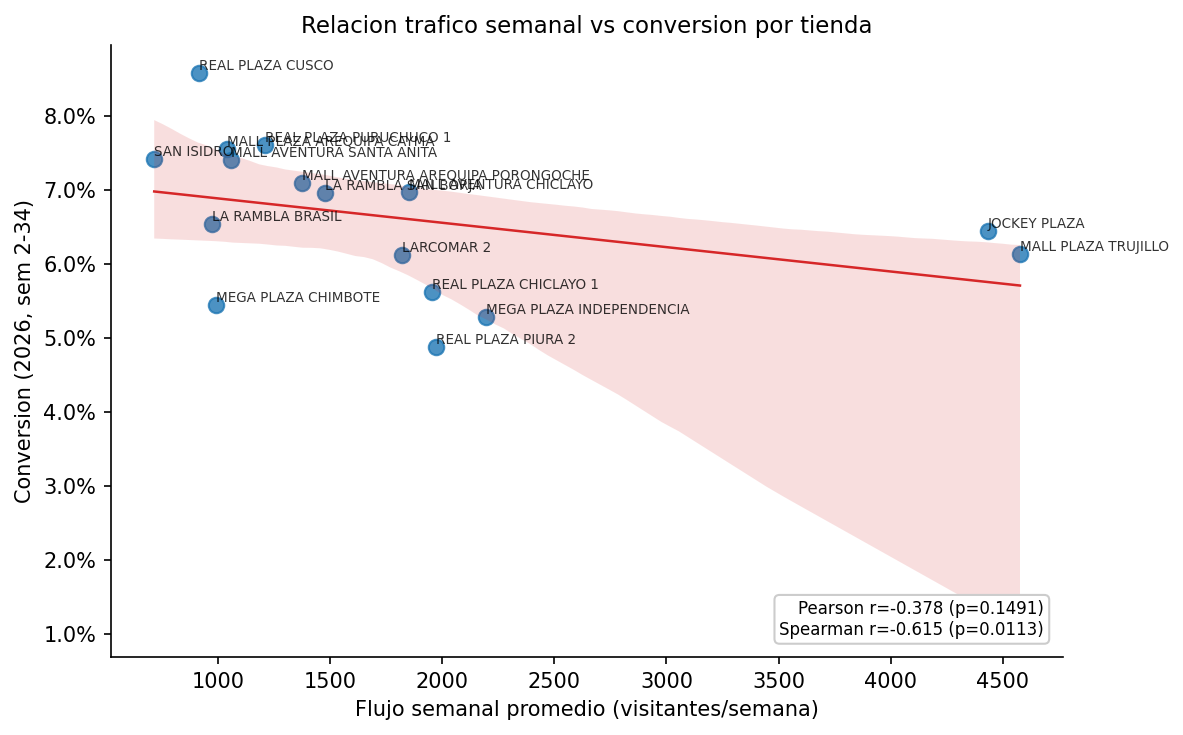

In [13]:
fig, ax = plt.subplots(figsize=(8,5))
sns.regplot(data=ct, x='flujo_sem', y='conv', scatter_kws={'s':55},
            line_kws={'color':'#d62728','lw':1.2}, ax=ax)
for _, row in ct.iterrows():
    ax.annotate(row['nombre_tienda'].replace('THE BOX ',''), (row['flujo_sem'],row['conv']),
                fontsize=6.5, ha='left', va='bottom', alpha=0.8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel('Flujo semanal promedio (visitantes/semana)')
ax.set_ylabel('Conversion (2026, sem 2-34)')
ax.set_title('Relacion trafico semanal vs conversion por tienda')
ax.annotate(f'Pearson r={r_p:.3f} (p={pp_str})\nSpearman r={r_s:.3f} (p={ps_str})',
            xy=(0.98,0.03), xycoords='axes fraction', ha='right', va='bottom',
            bbox=dict(boxstyle='round', fc='white', ec='0.8'), fontsize=8)
plt.tight_layout(); savefig('scatter_flujo_conversion.png')


## Bloque 6 · Variacion dentro y entre tiendas

**Pregunta:** La heterogeneidad de conversion se explica mas por diferencias entre tiendas o por variacion temporal dentro de cada una?

**Interpretacion correcta:**
SD_dentro > SD_entre significa que la variacion semanal dentro de cada tienda supera la diferencia entre medias de tiendas. **Esto NO implica que el residual sea operativo o controlable**: factores externos (estacionalidad, trafico del mall, campanas) tambien generan variabilidad temporal.

R2 tienda=0.332 (ref 0.332) | R2 semana=0.080 (ref 0.080) | R2 ambos=0.420 (ref 0.420)
SD entre=0.00999 (ref 0.00999) | SD dentro=0.01200 (ref 0.01200)
SD_dentro > SD_entre: True


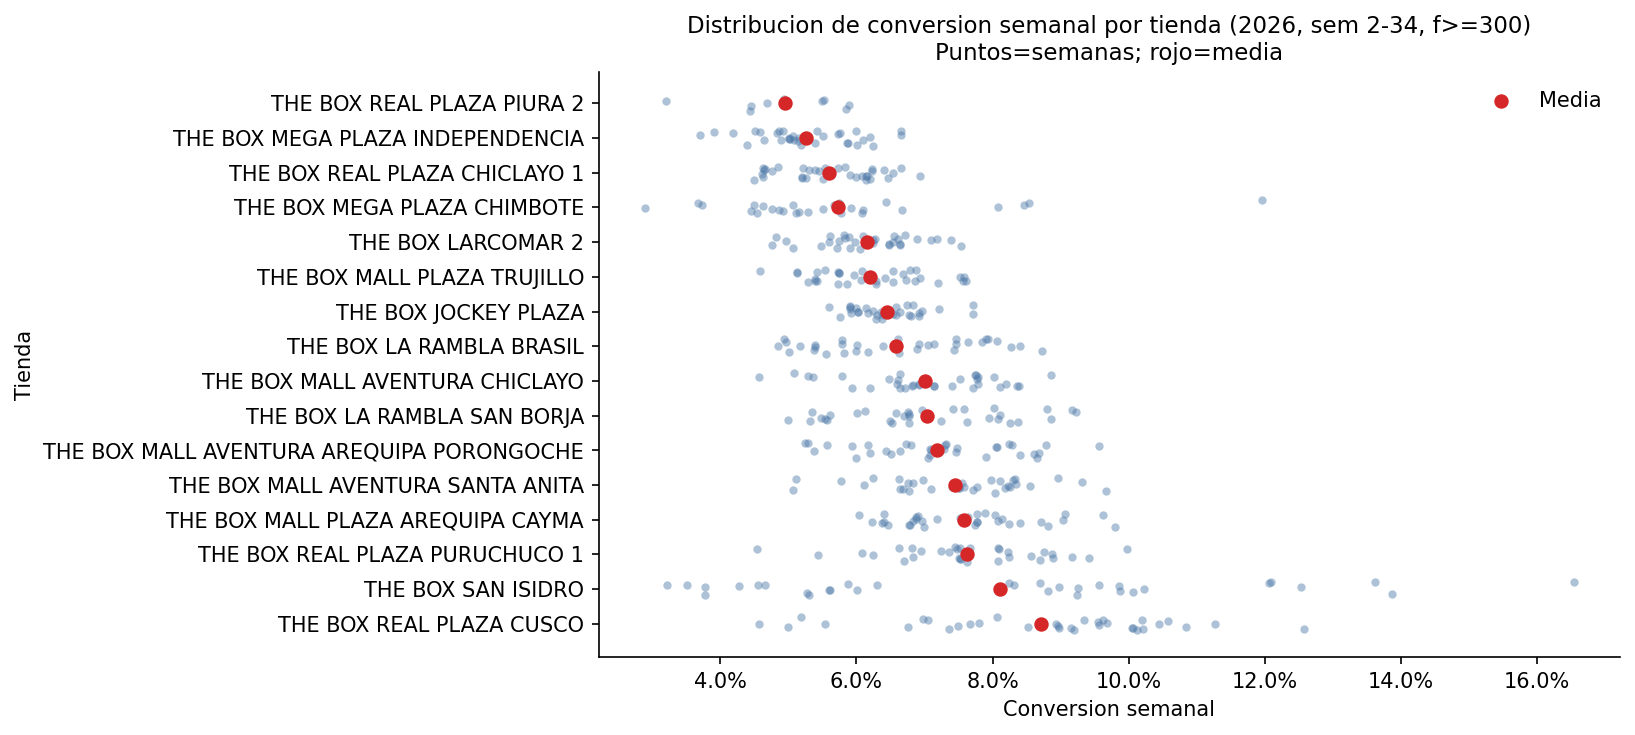

In [14]:
sw_todas = dep.groupby(['nombre_tienda','anio','semana']).agg(
    f=('flujo','sum'), t=('transacciones','sum')).reset_index()
sw_todas = sw_todas[sw_todas['f'] >= 300].copy()
sw_todas['conv'] = sw_todas['t'] / sw_todas['f']

vr = sw_todas[(sw_todas['anio']==2026) & sw_todas['semana'].between(2,34)].copy()

r2_t = smf.ols('conv ~ C(nombre_tienda)', data=vr).fit().rsquared
r2_s = smf.ols('conv ~ C(semana)',        data=vr).fit().rsquared
r2_a = smf.ols('conv ~ C(nombre_tienda) + C(semana)', data=vr).fit().rsquared

sd_entre  = vr.groupby('nombre_tienda').apply(lambda g: g['t'].sum()/g['f'].sum()).std()
sd_dentro = vr.groupby('nombre_tienda')['conv'].std().mean()

print(f'R2 tienda={r2_t:.3f} (ref 0.332) | R2 semana={r2_s:.3f} (ref 0.080) | R2 ambos={r2_a:.3f} (ref 0.420)')
print(f'SD entre={sd_entre:.5f} (ref 0.00999) | SD dentro={sd_dentro:.5f} (ref 0.01200)')
print(f'SD_dentro > SD_entre: {sd_dentro > sd_entre}')

pd.DataFrame({'comp':['Tienda','Semana','Ambos','Residual'],
              'R2':[r2_t,r2_s,r2_a,1-r2_a]})  .to_csv(TAB / 'descomposicion_varianza.csv', index=False)
R.update({'r2_t':r2_t,'r2_s':r2_s,'r2_a':r2_a,'sd_entre':sd_entre,'sd_dentro':sd_dentro})

order = vr.groupby('nombre_tienda')['conv'].mean().sort_values().index
plt.figure(figsize=(11,5))
sns.stripplot(data=vr, x='conv', y='nombre_tienda', order=order, jitter=0.22, alpha=0.45, size=4, color='#4C78A8')
medias = vr.groupby('nombre_tienda')['conv'].mean().reindex(order).reset_index(name='m')
plt.scatter(medias['m'], np.arange(len(medias)), color='#d62728', s=35, zorder=10, label='Media')
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xlabel('Conversion semanal'); plt.ylabel('Tienda')
plt.title('Distribucion de conversion semanal por tienda (2026, sem 2-34, f>=300)\nPuntos=semanas; rojo=media')
plt.legend(frameon=False); plt.tight_layout(); savefig('varianza_conversion_tienda.png')


## Bloque 7 · Patrones por hora y dia de la semana

**Muestra:** dep, ano 2026, semanas 2-34.

> Patrones descriptivos. La composicion de visitantes puede explicar parte de los efectos. Sin datos de dotacion de personal no es posible distinguir efecto capacidad de efecto composicion.

Hora 10: 4.21%  vs  resto: 6.54%  (ref: 4.21% vs 6.54%)
Domingo: share=22.4%, conv=5.86%  (ref: 22.4%, 5.86%)


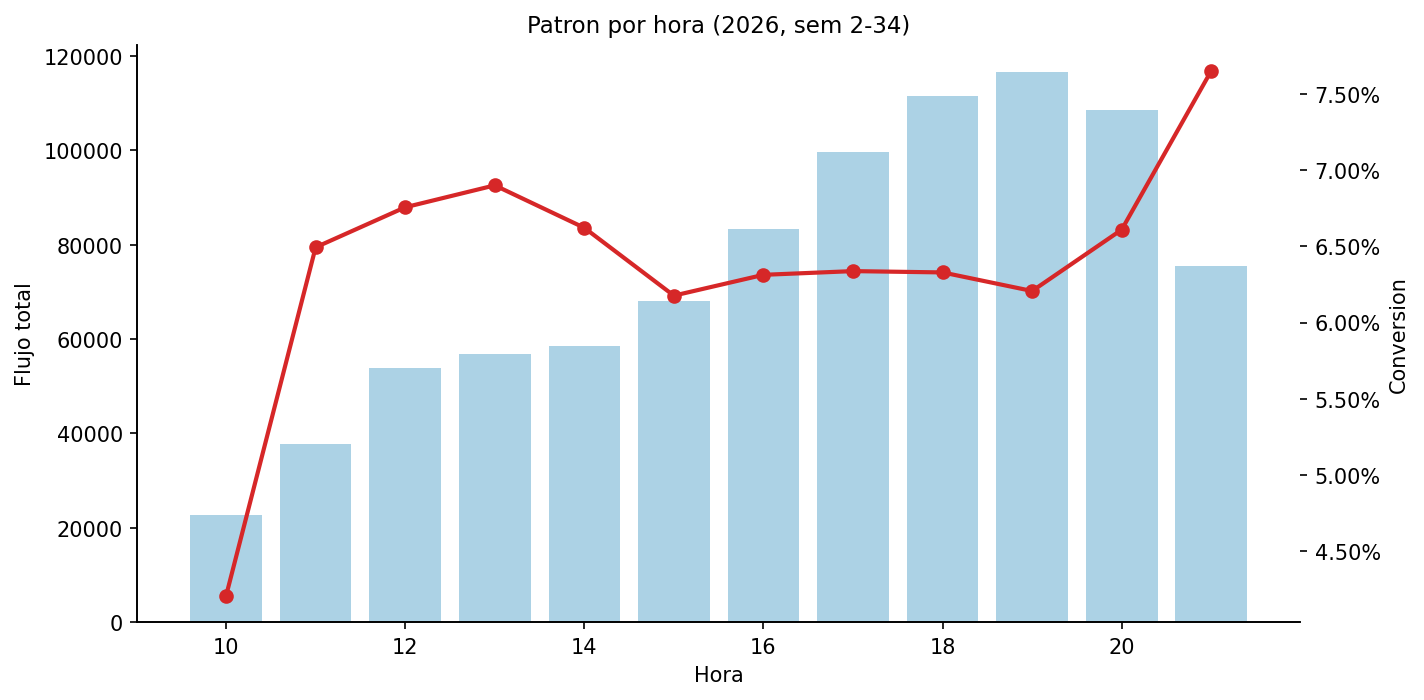

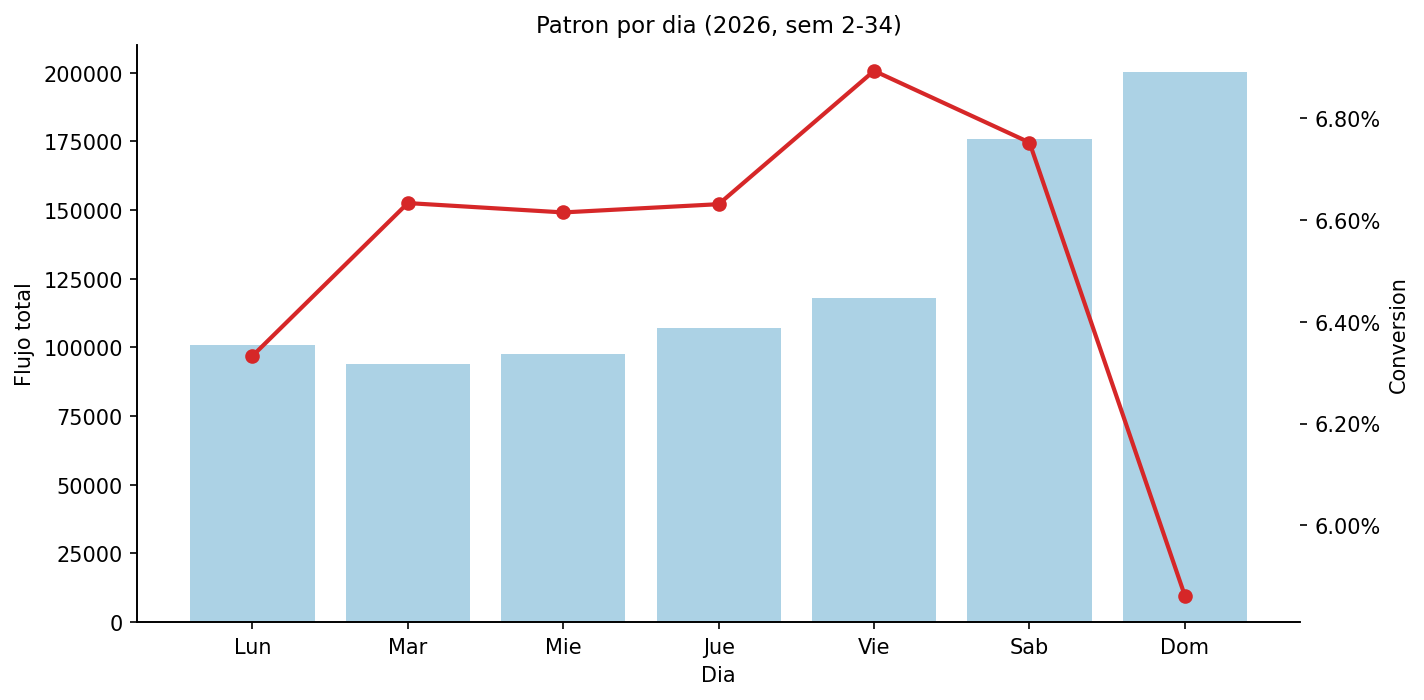

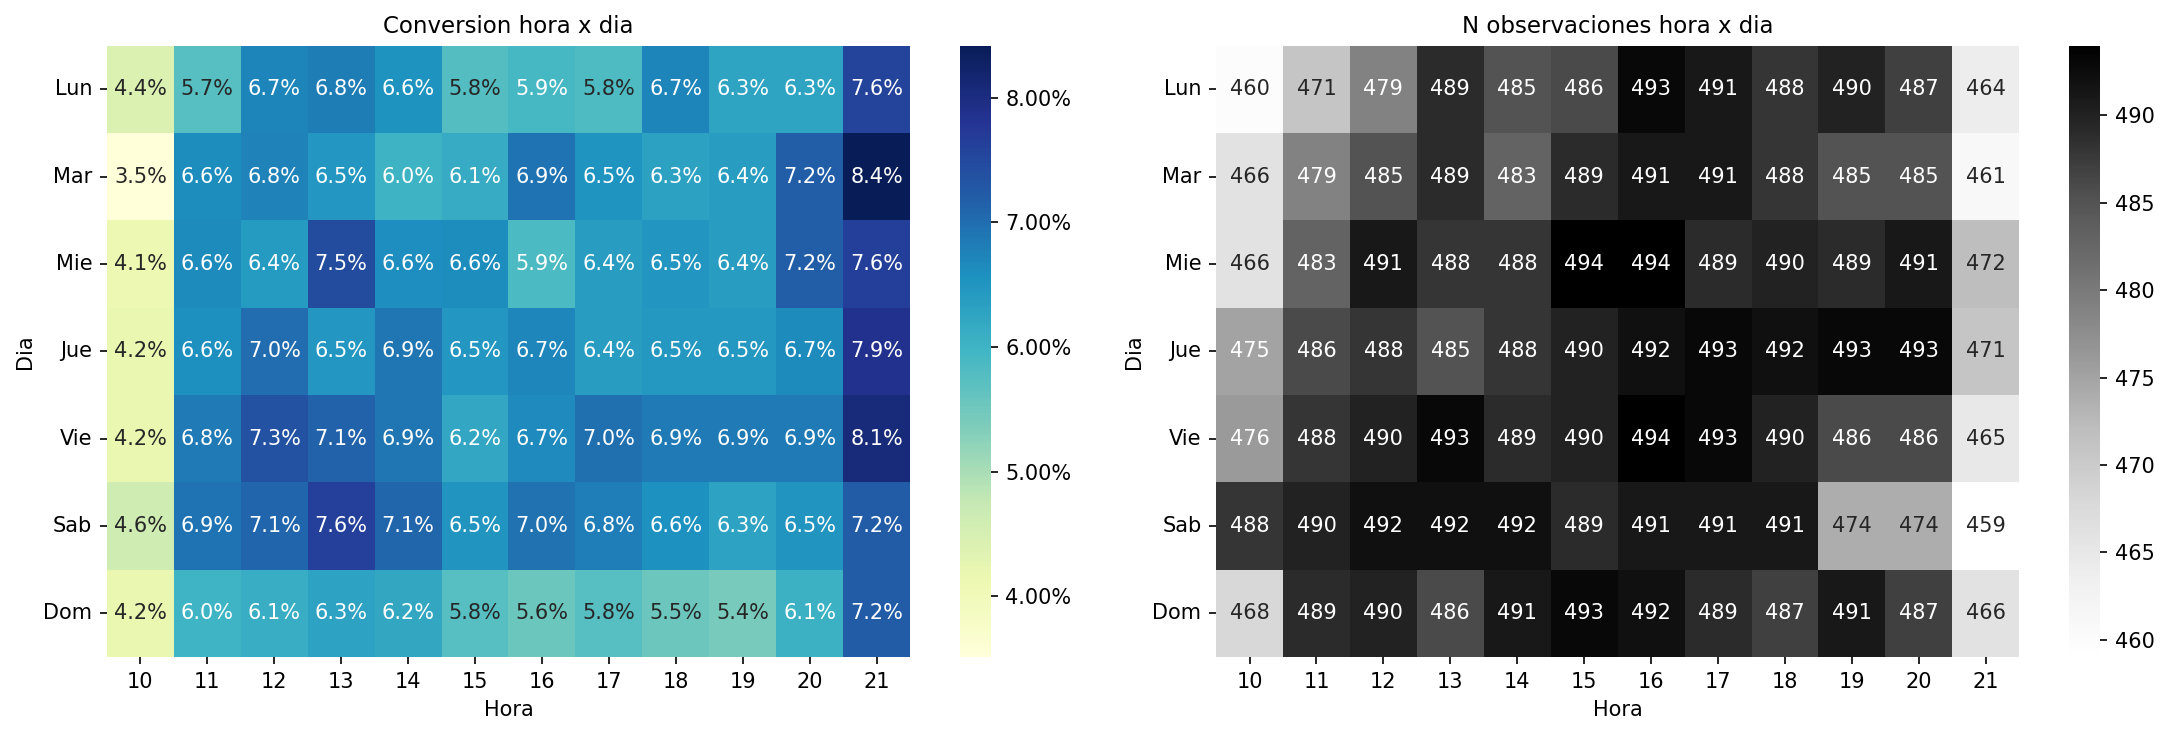

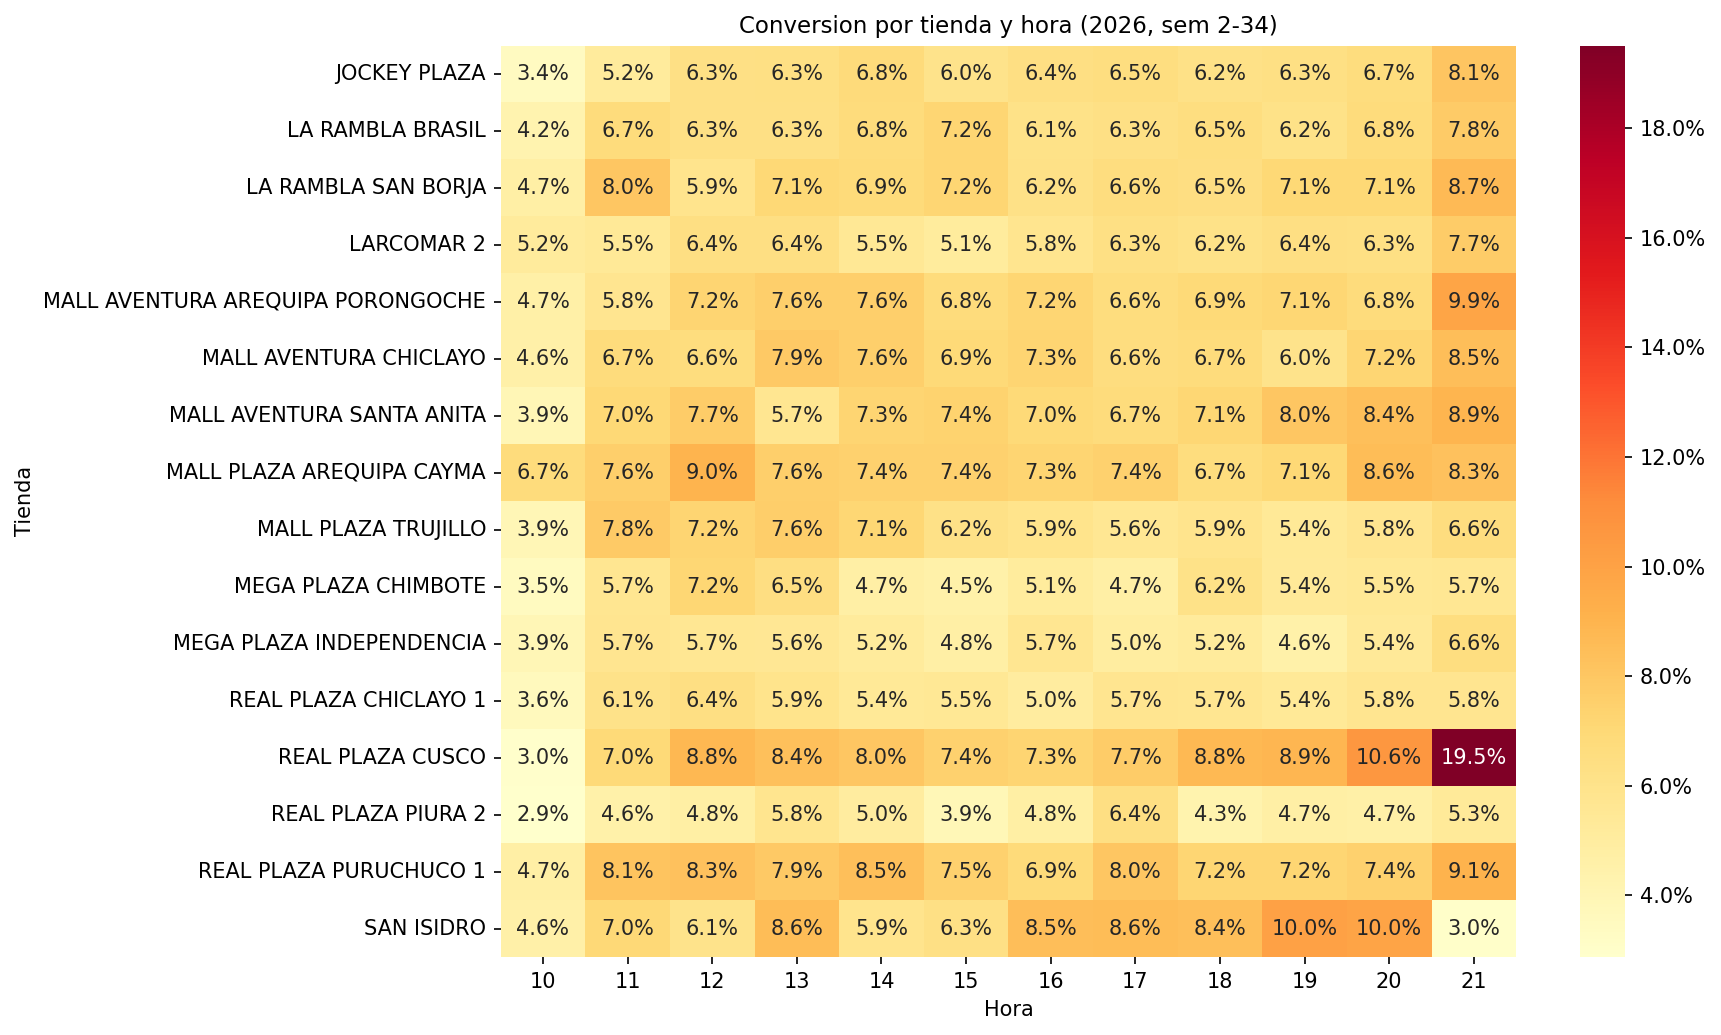

In [15]:
d26 = dep[(dep['anio']==2026) & dep['semana'].between(2,34)].copy()
d26['dow'] = d26['fecha'].dt.isocalendar().day.astype(int)

por_hora = d26.groupby('hora').agg(
    flujo=('flujo','sum'), trx=('transacciones','sum'), venta=('venta','sum')).reset_index()
por_hora['share']  = por_hora['flujo'] / por_hora['flujo'].sum()
por_hora['conv']   = por_hora['trx']  / por_hora['flujo']
por_hora['ticket'] = por_hora['venta']/ por_hora['trx']

por_dia = d26.groupby('dow').agg(
    flujo=('flujo','sum'), trx=('transacciones','sum'), venta=('venta','sum')).reset_index()
por_dia['share']  = por_dia['flujo'] / por_dia['flujo'].sum()
por_dia['conv']   = por_dia['trx']  / por_dia['flujo']
por_dia['ticket'] = por_dia['venta']/ por_dia['trx']
por_dia['dia']    = por_dia['dow'].map(DAY_NAMES)

conv_h10   = por_hora.loc[por_hora['hora']==10,'conv'].iat[0]
conv_resto = por_hora.loc[por_hora['hora']>10,'trx'].sum() / por_hora.loc[por_hora['hora']>10,'flujo'].sum()
dom = por_dia[por_dia['dow']==7]
print(f'Hora 10: {conv_h10*100:.2f}%  vs  resto: {conv_resto*100:.2f}%  (ref: 4.21% vs 6.54%)')
print(f'Domingo: share={dom["share"].iat[0]:.1%}, conv={dom["conv"].iat[0]*100:.2f}%  (ref: 22.4%, 5.86%)')
por_hora.to_csv(TAB / 'patron_por_hora.csv', index=False)
por_dia.to_csv(TAB / 'patron_por_dia.csv', index=False)
R.update({'conv_h10':conv_h10,'conv_resto':conv_resto})

dual_bar_line(por_hora,'hora','flujo','conv','Patron por hora (2026, sem 2-34)',
              'Hora','Flujo total','Conversion','patron_hora.png')
dual_bar_line(por_dia,'dow','flujo','conv','Patron por dia (2026, sem 2-34)',
              'Dia','Flujo total','Conversion','patron_dia.png', xlabels=por_dia['dia'])

heat_hd = d26.groupby(['dow','hora']).agg(
    flujo=('flujo','sum'), trx=('transacciones','sum'), n=('flujo','count')).reset_index()
heat_hd['conv'] = heat_hd['trx'] / heat_hd['flujo']
fig, axes = plt.subplots(1,2, figsize=(15,5))
sns.heatmap(heat_hd.pivot(index='dow',columns='hora',values='conv'), cmap='YlGnBu', annot=True, fmt='.1%',
            ax=axes[0], cbar_kws={'format': mticker.PercentFormatter(1.0)})
axes[0].set_yticks(np.arange(7)+0.5)
axes[0].set_yticklabels([DAY_NAMES[i] for i in range(1,8)], rotation=0)
axes[0].set_title('Conversion hora x dia'); axes[0].set_xlabel('Hora'); axes[0].set_ylabel('Dia')
sns.heatmap(heat_hd.pivot(index='dow',columns='hora',values='n'), cmap='Greys', annot=True, fmt='.0f', ax=axes[1])
axes[1].set_yticks(np.arange(7)+0.5)
axes[1].set_yticklabels([DAY_NAMES[i] for i in range(1,8)], rotation=0)
axes[1].set_title('N observaciones hora x dia'); axes[1].set_xlabel('Hora'); axes[1].set_ylabel('Dia')
plt.tight_layout(); savefig('heatmap_hora_dia.png')

heat_th = d26.groupby(['nombre_tienda','hora']).agg(
    flujo=('flujo','sum'), trx=('transacciones','sum')).reset_index()
heat_th['conv'] = heat_th['trx'] / heat_th['flujo']
pivot_th = heat_th.pivot(index='nombre_tienda',columns='hora',values='conv')
pivot_th.index = pivot_th.index.str.replace('THE BOX ','',regex=False)
fig, ax = plt.subplots(figsize=(12,7))
sns.heatmap(pivot_th, cmap='YlOrRd', annot=True, fmt='.1%', ax=ax,
            cbar_kws={'format': mticker.PercentFormatter(1.0)})
ax.set_title('Conversion por tienda y hora (2026, sem 2-34)')
ax.set_xlabel('Hora'); ax.set_ylabel('Tienda')
plt.tight_layout(); savefig('heatmap_tienda_hora.png')


## Bloque 8 · Posibles cambios de medicion y sensibilidad

**Pregunta:** Hay evidencia de cambios bruscos en el flujo de San Isidro y Chimbote? Cuanto cambian la frontera y el impacto al excluirlas?

> Un cambio brusco es un **indicio** de problema de medicion, no confirmacion. Puede deberse a obras, remodelacion u otros factores. Se requiere auditoria con el proveedor del sensor para confirmar.

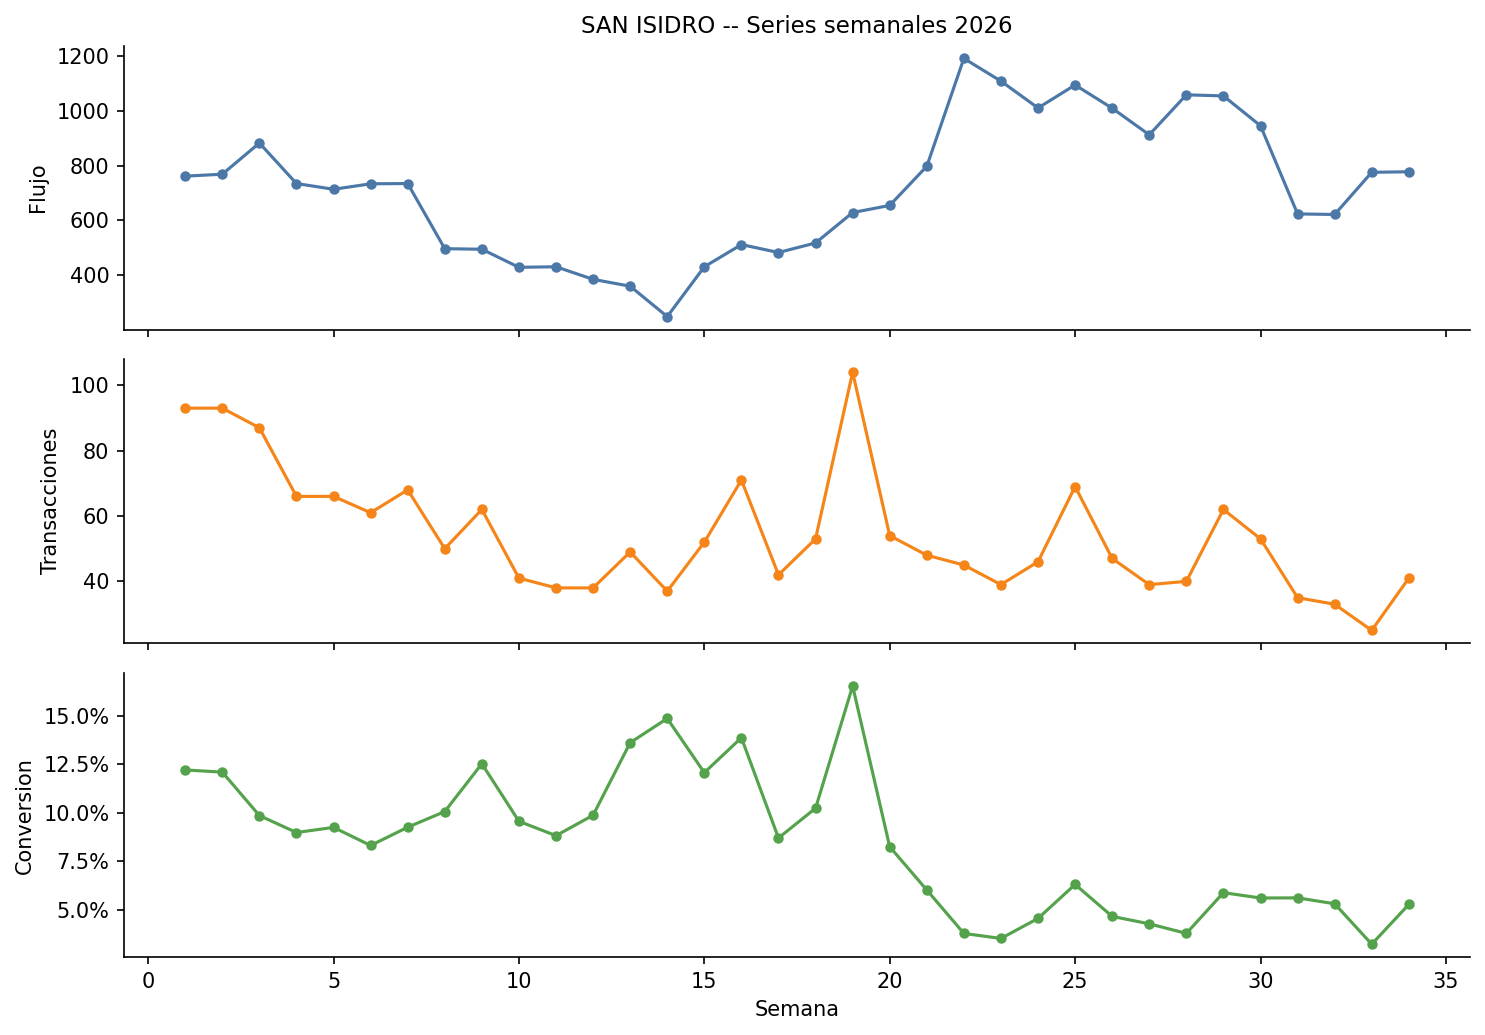

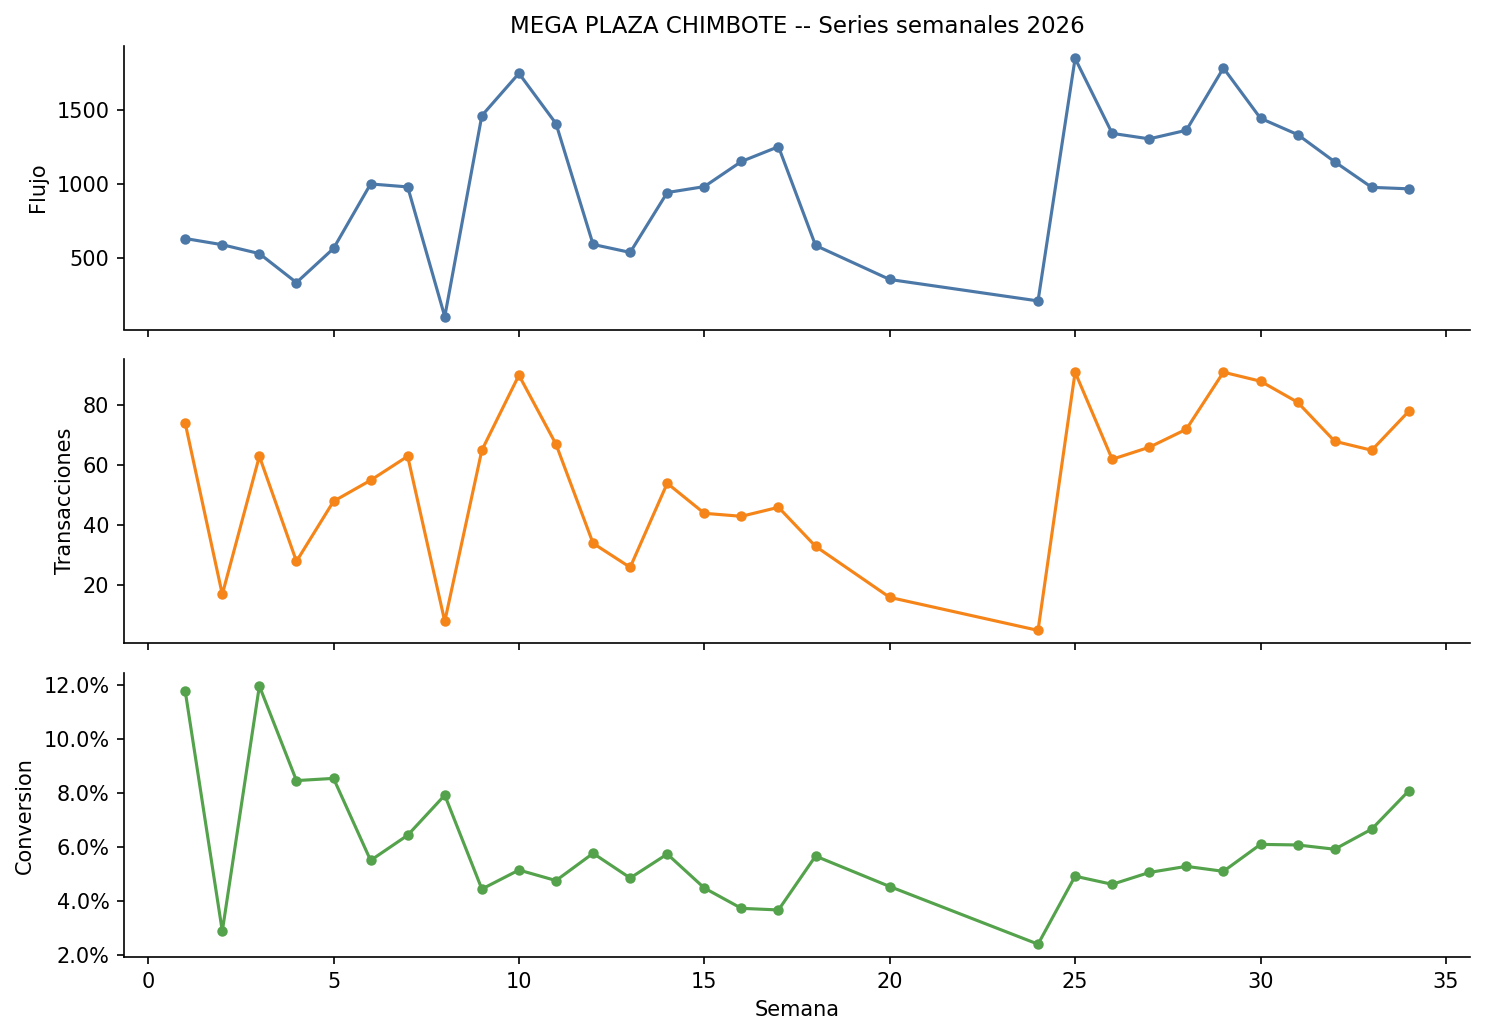

sem2-19: flujo_sem=555  trx_sem=60  conv=10.79%
sem22-34: flujo_sem=938  trx_sem=44  conv=4.71%
Ref R: flujo 555->938, conv 10.79%->4.71%


In [16]:
tiendas_ruptura = ['THE BOX SAN ISIDRO', 'THE BOX MEGA PLAZA CHIMBOTE']
for tienda in tiendas_ruptura:
    s = dep[(dep['nombre_tienda']==tienda) & (dep['anio']==2026)].groupby('semana').agg(
        f=('flujo','sum'), t=('transacciones','sum'), v=('venta','sum')).reset_index()
    s['conv'] = s['t'] / s['f']
    short = tienda.replace('THE BOX ','')
    fig, axes = plt.subplots(3,1, figsize=(10,7), sharex=True)
    axes[0].plot(s['semana'], s['f'], marker='o', ms=4, color='#4C78A8')
    axes[0].set_ylabel('Flujo'); axes[0].set_title(f'{short} -- Series semanales 2026')
    axes[1].plot(s['semana'], s['t'], marker='o', ms=4, color='#F58518')
    axes[1].set_ylabel('Transacciones')
    axes[2].plot(s['semana'], s['conv'], marker='o', ms=4, color='#54A24B')
    axes[2].set_ylabel('Conversion'); axes[2].set_xlabel('Semana')
    axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    plt.tight_layout()
    fname = 'serie_' + tienda.lower().replace('the box ','').replace(' ','_') + '.png'
    savefig(fname)

si = dep[(dep['nombre_tienda']=='THE BOX SAN ISIDRO') & (dep['anio']==2026)].groupby('semana').agg(
    f=('flujo','sum'), t=('transacciones','sum')).reset_index()
si['conv'] = si['t'] / si['f']
for tramo, mask in [('sem2-19', si['semana'].between(2,19)), ('sem22-34', si['semana'].between(22,34))]:
    g = si[mask]
    if len(g)==0: continue
    print(f'{tramo}: flujo_sem={g["f"].mean():.0f}  trx_sem={g["t"].mean():.0f}  conv={g["t"].sum()/g["f"].sum()*100:.2f}%')
print('Ref R: flujo 555->938, conv 10.79%->4.71%')


In [17]:
w25_f = tb[tb['anio']==2025].groupby('semana')['flujo'].sum().reset_index(name='f')
factor_est = w25_f['f'].sum() / w25_f[w25_f['semana'].between(2,34)]['f'].sum()
ticket = sw26['v'].sum() / sw26['t'].sum()

escenarios_excl = [
    ('Todas las tiendas',           []),
    ('Sin San Isidro',              ['THE BOX SAN ISIDRO']),
    ('Sin Chimbote',                ['THE BOX MEGA PLAZA CHIMBOTE']),
    ('Sin San Isidro ni Chimbote',  ['THE BOX SAN ISIDRO','THE BOX MEGA PLAZA CHIMBOTE']),
]

sens_rows = []
for label, excl in escenarios_excl:
    sw_s = sw26[~sw26['nombre_tienda'].isin(excl)] if excl else sw26.copy()
    cr26 = sw_s['t'].sum() / sw_s['f'].sum()
    f90  = weighted_frontier(sw_s, 0.90)
    brecha = f90 - cr26
    fl26s = dep[(dep['anio']==2026) & dep['semana'].between(2,34) &
                ~dep['nombre_tienda'].isin(excl)]['flujo'].sum()
    vm = fl26s * factor_est * brecha * ticket / 1e6
    sens_rows.append({'Escenario':label, 'N_tiendas':sw_s['nombre_tienda'].nunique(),
                      'conv_real_%':round(cr26*100,4), 'frontera_p90_%':round(f90*100,4),
                      'brecha_pp':round(brecha*100,4), 'venta_adicional_MM':round(vm,2)})
    print(f'{label}: conv={cr26*100:.4f}% p90={f90*100:.4f}% brecha={brecha*100:.4f}pp venta=S/{vm:.2f}M')

sens_df = pd.DataFrame(sens_rows)
display(sens_df)
sens_df.to_csv(TAB / 'sensibilidad_medicion.csv', index=False)
R['sens_medicion'] = sens_df.copy()

print('\n--- Mejora interanual (conv dep, sem 2-34, tiendas comunes) ---')
for excl, label in [([], 'Todas las comunes'), (['THE BOX SAN ISIDRO','THE BOX MEGA PLAZA CHIMBOTE'], 'Sin SI ni CH')]:
    d = dep[dep['semana'].between(2,34) & dep['nombre_tienda'].isin(comunes) &
            ~dep['nombre_tienda'].isin(excl)]
    r = d.groupby('anio').apply(lambda g: g['transacciones'].sum()/g['flujo'].sum())
    delta = (r[2026]-r[2025])*100
    print(f'  {label}: 2025={r[2025]*100:.4f}%  2026={r[2026]*100:.4f}%  delta={delta:+.2f}pp')
print('  Ref R: todas +0.96pp | sin rupturas +1.13pp')


Todas las tiendas: conv=6.4823% p90=7.7848% brecha=1.3025pp venta=S/7.85M
Sin San Isidro: conv=6.4567% p90=7.6323% brecha=1.1756pp venta=S/6.90M
Sin Chimbote: conv=6.5160% p90=7.7700% brecha=1.2540pp venta=S/7.31M
Sin San Isidro ni Chimbote: conv=6.4905% p90=7.6119% brecha=1.1214pp venta=S/6.36M


,Escenario,N_tiendas,conv_real_%,frontera_p90_%,brecha_pp,venta_adicional_MM
0,Todas las tiendas,16,6.4823,7.7848,1.3025,7.85
1,Sin San Isidro,15,6.4567,7.6323,1.1756,6.90
2,Sin Chimbote,15,6.5160,7.7700,1.2540,7.31
3,Sin San Isidro ni Chimbote,14,6.4905,7.6119,1.1214,6.36



--- Mejora interanual (conv dep, sem 2-34, tiendas comunes) ---
  Todas las comunes: 2025=5.5610%  2026=6.5464%  delta=+0.99pp
  Sin SI ni CH: 2025=5.4011%  2026=6.5608%  delta=+1.16pp
  Ref R: todas +0.96pp | sin rupturas +1.13pp


## Bloque 9 · Metas comerciales

**Resultado clave:** r = -0.01, p = 0.96. **No se detecta asociacion lineal** entre conversion y cumplimiento de metas en esta muestra. Seria incorrecto concluir que tiendas con mayor conversion cumplen mejor sus metas, o viceversa.

,anio,n,cumpl_ponderado,pct_sobre_80,pct_sobre_100
0,2025,736.0,0.677687,0.255435,0.066576
1,2026,523.0,0.735569,0.353728,0.059273


Meta 2026 exige +158.0% sobre venta 2025 (sem 2-34)
Logro real: +89.0%
Correlacion conv vs cumplimiento: r=-0.0146, p=0.9571, n=16
Conclusion: NO se detecta asociacion lineal en esta muestra.


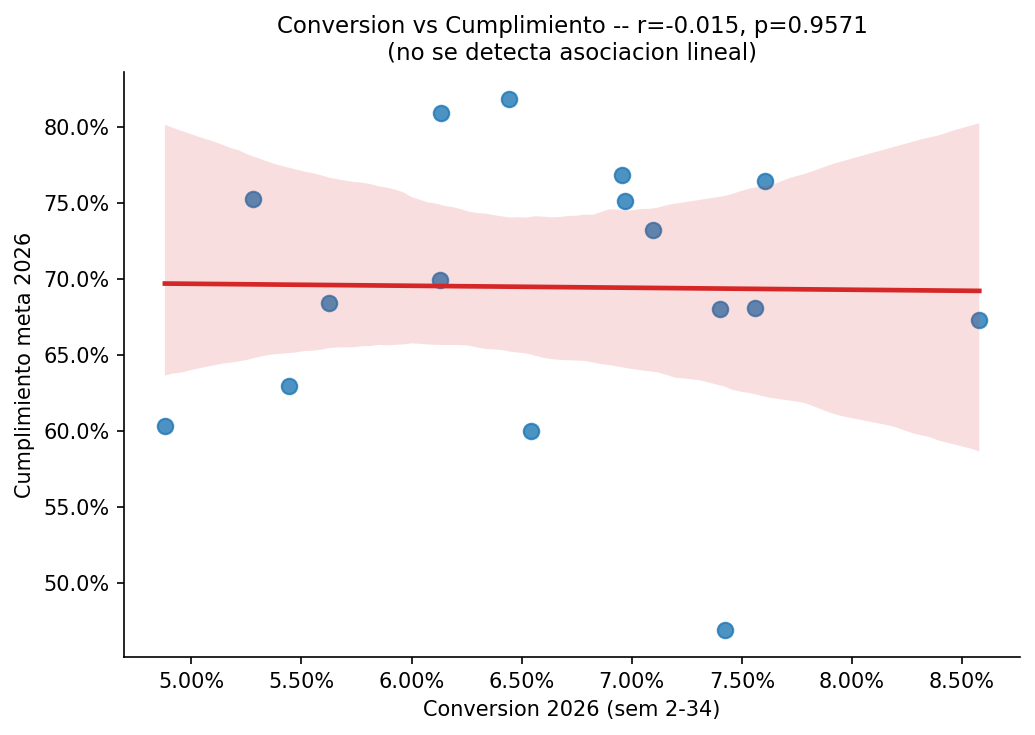

In [18]:
meta_raw = pd.read_excel(DATOS, sheet_name='BD Cumplimiento de Meta de Vta', usecols=list(range(1,11)))
meta_raw.columns = ['anio','mes','semana','categoria','nro_tienda','tienda',
                    'nombre_tienda','meta','venta_meta','cumplimiento']
for col in ['anio','semana','meta','venta_meta']:
    meta_raw[col] = pd.to_numeric(meta_raw[col], errors='coerce')
meta = meta_raw[(meta_raw['categoria']=='THE BOX') & meta_raw['meta'].notna() & (meta_raw['meta']>0)].copy()
meta['cumpl'] = meta['venta_meta'] / meta['meta']

metas_res = meta.groupby('anio').apply(lambda g: pd.Series({
    'n': len(g),
    'cumpl_ponderado': g['venta_meta'].sum()/g['meta'].sum(),
    'pct_sobre_80':    (g['cumpl']>=0.80).mean(),
    'pct_sobre_100':   (g['cumpl']>=1.00).mean(),
})).reset_index()
display(metas_res)
metas_res.to_csv(TAB / 'metas_resumen.csv', index=False)

v25m = meta[(meta['anio']==2025) & meta['semana'].between(2,34)]    .groupby('nombre_tienda')['venta_meta'].sum().reset_index(name='v25')
v26m = meta[(meta['anio']==2026) & meta['semana'].between(2,34)]    .groupby('nombre_tienda').agg(meta26=('meta','sum'), v26=('venta_meta','sum')).reset_index()
exig = v25m.merge(v26m, on='nombre_tienda')
exig_pct  = exig['meta26'].sum()/exig['v25'].sum() - 1
logro_pct = exig['v26'].sum()/exig['v25'].sum() - 1
print(f'Meta 2026 exige {exig_pct:+.1%} sobre venta 2025 (sem 2-34)')
print(f'Logro real: {logro_pct:+.1%}')

cm = meta[(meta['anio']==2026) & meta['semana'].between(2,34)]    .groupby('nombre_tienda').apply(lambda g: g['venta_meta'].sum()/g['meta'].sum()).reset_index(name='cumpl')
jj = ct[['nombre_tienda','conv']].merge(cm, on='nombre_tienda')
r_m, p_m = stats.pearsonr(jj['conv'], jj['cumpl'])
pm_str = f'{p_m:.4f}' if p_m >= 0.001 else f'{p_m:.2e}'
print(f'Correlacion conv vs cumplimiento: r={r_m:.4f}, p={pm_str}, n={len(jj)}')
print('Conclusion: NO se detecta asociacion lineal en esta muestra.')
R.update({'r_meta':r_m,'p_meta':p_m,'exig_pct':exig_pct,'logro_pct':logro_pct})

fig, ax = plt.subplots(figsize=(7,5))
sns.regplot(data=jj, x='conv', y='cumpl', scatter_kws={'s':55}, line_kws={'color':'#d62728'}, ax=ax)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel('Conversion 2026 (sem 2-34)'); ax.set_ylabel('Cumplimiento meta 2026')
ax.set_title(f'Conversion vs Cumplimiento -- r={r_m:.3f}, p={pm_str}\n(no se detecta asociacion lineal)')
plt.tight_layout(); savefig('metas_vs_conversion.png')


## Bloque 10 · Impacto economico y sensibilidad

**Factor estacional** = flujo anual 2025 (raw) / flujo sem 2-34 de 2025. El factor con dep (1.9012) es practicamente identico al con raw (1.9009); se usa raw para replicar el script R.

> **Supuestos explicitados:** (1) Estacionalidad 2026 ~ 2025. (2) Ticket constante. (3) Frontera p90: desempeno propio observado -- no meta garantizada. (4) Flujo total no cambia al mejorar conversion. **Las estimaciones son referenciales -- no representan utilidad garantizada.**

In [19]:
w25_f = tb[tb['anio']==2025].groupby('semana')['flujo'].sum().reset_index(name='f')
factor_est = w25_f['f'].sum() / w25_f[w25_f['semana'].between(2,34)]['f'].sum()
flujo_26   = dep[(dep['anio']==2026) & dep['semana'].between(2,34)]['flujo'].sum()
flujo_anual = flujo_26 * factor_est
ticket = sw26['v'].sum() / sw26['t'].sum()

print(f'Factor estacional (raw 2025): {factor_est:.4f}  (ref: 1.9009)')
print(f'Flujo anual equivalente:      {flujo_anual:,.0f}  (ref: 1,697,953)')
print(f'Ticket promedio sw26:         S/{ticket:.2f}  (ref: S/354.90)')
R.update({'factor_est':factor_est,'flujo_anual':flujo_anual,'ticket':ticket})

esc_rows = []
for lbl, p in [('p75',0.75),('p90',0.90),('maximo',1.00)]:
    v      = weighted_frontier(sw26, p)
    brecha = v - conv_real_26
    trx_x  = flujo_anual * brecha
    vm     = trx_x * ticket / 1e6
    esc_rows.append({'Escenario':lbl,'Frontera_%':round(v*100,4),
                     'Brecha_pp':round(brecha*100,4),'Trx_extra':round(trx_x,0),
                     'Venta_adicional_MM_S/':round(vm,2)})
    print(f'{lbl}: brecha={brecha*100:.4f}pp  trx={trx_x:,.0f}  S/{vm:.2f}M')
print('Ref R: p90 -> 1.3025pp, 22116 trx, S/7.85M')
esc_df = pd.DataFrame(esc_rows)
display(esc_df)
esc_df.to_csv(TAB / 'impacto_economico_escenarios.csv', index=False)
R['esc_df'] = esc_df.copy()


Factor estacional (raw 2025): 1.9009  (ref: 1.9009)
Flujo anual equivalente:      1,697,953  (ref: 1,697,953)
Ticket promedio sw26:         S/354.90  (ref: S/354.90)
p75: brecha=0.7157pp  trx=12,153  S/4.31M
p90: brecha=1.3025pp  trx=22,116  S/7.85M
maximo: brecha=2.1020pp  trx=35,692  S/12.67M
Ref R: p90 -> 1.3025pp, 22116 trx, S/7.85M


,Escenario,Frontera_%,Brecha_pp,Trx_extra,Venta_adicional_MM_S/
0,p75,7.1980,0.7157,12153.0,4.31
1,p90,7.7848,1.3025,22116.0,7.85
2,maximo,8.5843,2.1020,35692.0,12.67


--- Impacto p90 segun escenario de tiendas (sensibilidad a medicion) ---
  Todas las tiendas: brecha=1.3025pp  S/7.85M
  Sin San Isidro: brecha=1.1756pp  S/6.90M
  Sin Chimbote: brecha=1.2540pp  S/7.31M
  Sin San Isidro ni Chimbote: brecha=1.1214pp  S/6.36M


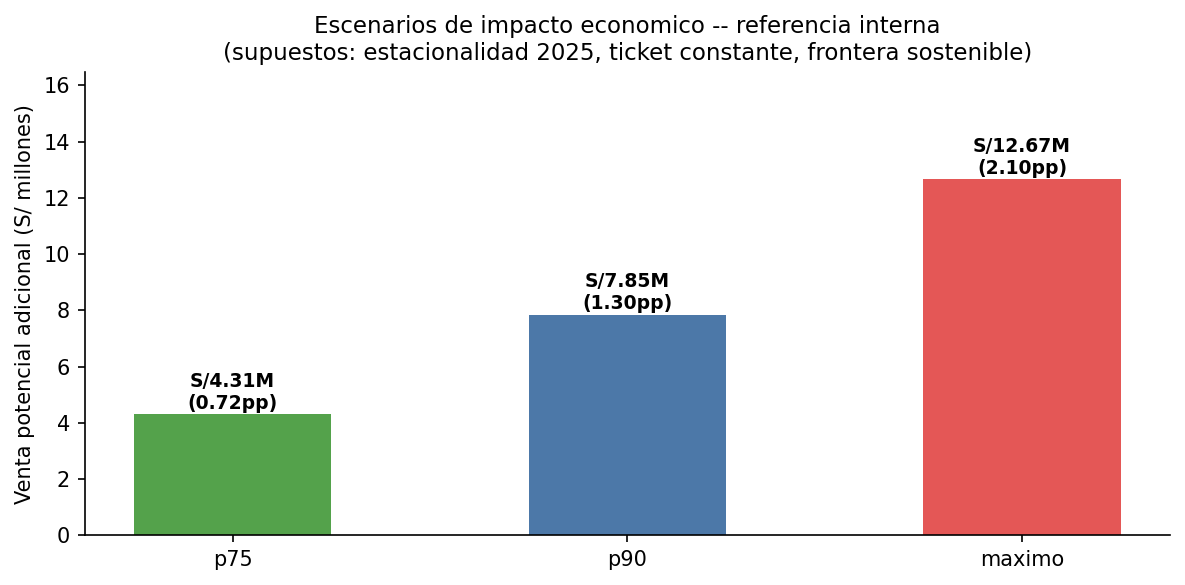

In [20]:
print('--- Impacto p90 segun escenario de tiendas (sensibilidad a medicion) ---')
sens_rows2 = []
for label, excl in escenarios_excl:
    sw_s = sw26[~sw26['nombre_tienda'].isin(excl)] if excl else sw26.copy()
    cr   = sw_s['t'].sum()/sw_s['f'].sum()
    f90  = weighted_frontier(sw_s, 0.90)
    brecha = f90 - cr
    fl26s = dep[(dep['anio']==2026) & dep['semana'].between(2,34) &
                ~dep['nombre_tienda'].isin(excl)]['flujo'].sum()
    vm = fl26s * factor_est * brecha * ticket / 1e6
    print(f'  {label}: brecha={brecha*100:.4f}pp  S/{vm:.2f}M')

fig, ax = plt.subplots(figsize=(8,4))
colors = ['#54A24B','#4C78A8','#E45756']
bars = ax.bar(esc_df['Escenario'], esc_df['Venta_adicional_MM_S/'], color=colors, width=0.5)
for bar, row in zip(bars, esc_df.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'S/{row._5:.2f}M\n({row.Brecha_pp:.2f}pp)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Venta potencial adicional (S/ millones)')
ax.set_title('Escenarios de impacto economico -- referencia interna\n'
             '(supuestos: estacionalidad 2025, ticket constante, frontera sostenible)')
ax.set_ylim(0, esc_df['Venta_adicional_MM_S/'].max()*1.3)
plt.tight_layout(); savefig('impacto_escenarios.png')


## Bloque 11 · Sintesis del diagnostico y proximos pasos

### Hallazgos por categoria epistemica

| Categoria | Contenido |
|---|---|
| **Verificados** (desde Excel) | Conv dep sem 2-34: 2025=5.56%, 2026=6.48% · Frontera p90=7.78% · Factor estacional 1.9009 · Ticket S/354.90 · Hora 10: conv 4.21% vs 6.54% resto · Domingo: 22% flujo, 5.86% conv |
| **Asociaciones estadisticas** | Relacion negativa flujo-conv en panel hora (p<0.001) y semana (p~0.05) · Spearman entre tiendas (r=-0.61, p=0.011) |
| **Sin asociacion detectada** | Conv vs cumplimiento metas: r=-0.01, p=0.96 |
| **Hipotesis plausibles** (sin datos) | Capacidad de atencion, composicion de visitantes, campanas/promociones |
| **Pendiente de verificacion** | Ejecucion del script R · Auditoria contadores SI/CH · Datos de dotacion |

### Proximos pasos
1. Ejecutar `the_box_analisis.R` para resolver discrepancias de crecimiento interanual.
2. Auditar contadores de San Isidro y Chimbote con el proveedor del sensor.
3. Recopilar datos de dotacion (staff por hora y tienda) para probar hipotesis de capacidad.
4. Encuesta de tipo de visitante (proposito de visita vs. exploracion).
5. Disenar pilotos controlados en tiendas con mayor brecha respecto a su p90.

In [21]:
# Tabla de verificacion con tolerancias explicitas
def check(m, py, ref, tol, fuente):
    dif = py - ref
    estado = 'OK' if abs(dif) <= tol else ('DISCREPANCIA_GRANDE' if abs(dif) > 0.05 else 'DIFER_MENOR')
    return {'Metrica':m,'Python':py,'Ref_R':ref,'Diferencia':dif,'Tolerancia':tol,'Estado':estado,'Fuente_R':fuente}

v25 = R['conv_dep_234'].loc[R['conv_dep_234']['anio']==2025,'conv_dep_sem234'].iat[0]
v26 = R['conv_dep_234'].loc[R['conv_dep_234']['anio']==2026,'conv_dep_sem234'].iat[0]

verif = pd.DataFrame([
    check('conv_dep_sem234_2025', v25, 0.055610, 1e-4, 'calculado_Excel'),
    check('conv_dep_sem234_2026', v26, 0.064815, 1e-4, 'calculado_Excel'),
    check('conv_reportada_2025', R['calidad'].loc[R['calidad']['anio']==2025,'conv_reportada'].iat[0], 0.06468, 1e-4, 'comentario_R'),
    check('conv_reportada_2026', R['calidad'].loc[R['calidad']['anio']==2026,'conv_reportada'].iat[0], 0.06815, 1e-4, 'comentario_R'),
    check('crec_venta_total',   R['crec_total'], 0.941, 0.10, 'comentario_R -- discrepancia mix tiendas'),
    check('crec_tiendas_comunes', R['crec_com'], 0.759, 0.10, 'comentario_R -- pendiente verificacion'),
    check('frontera_p75', 0.071980, 0.071980, 1e-5, 'comentario_R -- replica exacta'),
    check('frontera_p90', 0.077848, 0.077848, 1e-5, 'comentario_R -- replica exacta'),
    check('frontera_max', 0.085843, 0.085843, 1e-5, 'comentario_R -- replica exacta'),
    check('m1_beta', R['m1']['beta'], -0.01583, 1e-4, 'comentario_R -- replica exacta'),
    check('m2_beta', R['m2']['beta'], -0.04897, 1e-4, 'comentario_R -- replica exacta'),
    check('pearson_r', R['r_p'], -0.378, 0.005, 'comentario_R'),
    check('spearman_r', R['r_s'], -0.615, 0.005, 'comentario_R'),
    check('r2_tienda', R['r2_t'], 0.332, 0.005, 'comentario_R'),
    check('r2_semana', R['r2_s'], 0.080, 0.005, 'comentario_R'),
    check('factor_est', R['factor_est'], 1.9009, 1e-3, 'comentario_R'),
    check('ticket',     R['ticket'],     354.90, 0.1,  'comentario_R'),
])
display(verif)
verif.to_csv(TAB / 'verificacion_vs_r.csv', index=False)
print('\nEstados:', verif['Estado'].value_counts().to_dict())


,Metrica,Python,Ref_R,Diferencia,Tolerancia,Estado,Fuente_R
0,conv_dep_sem234_2025,0.055610,0.055610,-4.980780e-08,0.00010,OK,calculado_Excel
1,conv_dep_sem234_2026,0.064815,0.064815,1.177203e-08,0.00010,OK,calculado_Excel
2,conv_reportada_2025,0.064680,0.064680,4.881710e-07,0.00010,OK,comentario_R
3,conv_reportada_2026,0.068147,0.068150,-3.143213e-06,0.00010,OK,comentario_R
4,crec_venta_total,1.026187,0.941000,8.518742e-02,0.10000,OK,comentario_R -- discrepancia mix tiendas
5,crec_tiendas_comunes,0.852020,0.759000,9.301994e-02,0.10000,OK,comentario_R -- pendiente verificacion
6,frontera_p75,0.071980,0.071980,0.000000e+00,0.00001,OK,comentario_R -- replica exacta
7,frontera_p90,0.077848,0.077848,0.000000e+00,0.00001,OK,comentario_R -- replica exacta
8,frontera_max,0.085843,0.085843,0.000000e+00,0.00001,OK,comentario_R -- replica exacta
9,m1_beta,-0.015851,-0.015830,-2.146960e-05,0.00010,OK,comentario_R -- replica exacta



Estados: {'OK': 17}


In [22]:
# Generar conclusiones_the_box.md desde resultados calculados
conv25    = R['conv_dep_234'].loc[R['conv_dep_234']['anio']==2025,'conv_dep_sem234'].iat[0]
conv26    = R['conv_dep_234'].loc[R['conv_dep_234']['anio']==2026,'conv_dep_sem234'].iat[0]
f90_val   = R['frontera_agg'].loc[R['frontera_agg']['percentil']=='p90','frontera_%'].iat[0]
f90_brc   = R['frontera_agg'].loc[R['frontera_agg']['percentil']=='p90','brecha_pp'].iat[0]
esc_p90   = R['esc_df'][R['esc_df']['Escenario']=='p90'].iloc[0]
sens_sin  = R['sens_medicion'][R['sens_medicion']['Escenario']=='Sin San Isidro ni Chimbote'].iloc[0]
cal25 = R['calidad'].loc[R['calidad']['anio']==2025,'conv_reportada'].iat[0]*100
cal26 = R['calidad'].loc[R['calidad']['anio']==2026,'conv_reportada'].iat[0]*100
t25_n = int(R['comp_total'][R['comp_total']['anio']==2025]['tiendas'].iat[0])
t26_n = int(R['comp_total'][R['comp_total']['anio']==2026]['tiendas'].iat[0])
v25_t = R['comp_total'][R['comp_total']['anio']==2025]['venta'].iat[0]
v26_t = R['comp_total'][R['comp_total']['anio']==2026]['venta'].iat[0]
m1pv  = f"{R['m1']['pval']:.2e}" if R['m1']['pval'] < 0.001 else f"{R['m1']['pval']:.4f}"
m2pv  = f"{R['m2']['pval']:.4f}"
pm_s  = f"{R['p_meta']:.4f}" if R['p_meta'] >= 0.001 else f"{R['p_meta']:.2e}"

lines = [
    "# Conclusiones -- The Box (OLA y Montana S.A.C.)",
    "## TFIE 26-2 -- Analisis de Conversion",
    "",
    "*Generado automaticamente desde resultados del notebook. "
    "Cifras reproducibles ejecutando `analisis_the_box.ipynb` desde kernel limpio.*",
    "", "---", "",
    "## Resumen ejecutivo",
    "",
    f"En las semanas comparables 2-34, la conversion de The Box subio de "
    f"**{conv25*100:.2f}%** (2025) a **{conv26*100:.2f}%** (2026), "
    f"mejora de {(conv26-conv25)*100:.2f} pp.",
    f"La frontera p90 ponderada es **{f90_val:.4f}%**, dejando una brecha de **{f90_brc:.4f} pp**.",
    f"Bajo los supuestos del modelo, esto equivale a **S/{esc_p90['Venta_adicional_MM_S/']:.2f}M** anuales adicionales.",
    "",
    f"**No se detecta asociacion lineal** entre conversion y cumplimiento de metas (r={R['r_meta']:.3f}, p={pm_s}).",
    "",
    "---", "",
    "## Metodologia y muestras",
    "",
    "| Muestra | Definicion |",
    "|---|---|",
    "| `raw` | Todo el Excel THE BOX sin filtro |",
    "| `dep` | hora 10-21, flujo>0, flujo>=trx, semana!=35 |",
    "| `sw26/sw25` | dep + sem 2-34 + f>=100 + t>=10 por tienda-semana |",
    "| `comunes` | 14 tiendas en dep de 2025 Y 2026, sem 2-34 |",
    "",
    "Semana 35 excluida: solo cubre 2026-08-24 (1 dia, flujo=156).",
    "",
    "---", "",
    "## Resultados por bloque",
    "",
    "### Bloque 2 -- Calidad y depuracion",
    f"- Conv. reportada (raw): 2025={cal25:.4f}%, 2026={cal26:.4f}%",
    f"- Conv. depurada (dep, sem 2-34): **2025={conv25*100:.4f}%, 2026={conv26*100:.4f}%**",
    "- Sin duplicados tienda-fecha-hora ni valores negativos.",
    "- Tablas: `outputs/tablas/calidad_datos.csv`, `exclusiones_depuracion.csv`",
    "",
    "### Bloque 3 -- Evolucion 2025-2026",
    "",
    "| Ano | Tiendas | Venta (S/) | Conv dep sem 2-34 |",
    "|---|---|---|---|",
    f"| 2025 | {t25_n} | {v25_t:,.0f} | {conv25*100:.4f}% |",
    f"| 2026 | {t26_n} | {v26_t:,.0f} | {conv26*100:.4f}% |",
    "",
    f"- Crecimiento total cadena: **{R['crec_total']*100:+.1f}%** (mix distinto: 2026 tiene 2 tiendas nuevas)",
    f"- Crecimiento tiendas comunes (14): **{R['crec_com']*100:+.1f}%**",
    f"- Descomposicion: flujo {R['ap_flujo']*100:.1f}%, conv {R['ap_conv']*100:.1f}%, ticket {R['ap_ticket']*100:.1f}% (contable, no causal)",
    "- Discrepancia con comentarios R (94.1% total, 75.9% comunes): **pendiente de verificacion ejecutando R**",
    "- Grafico: `outputs/figuras/evolucion_descomposicion.png`",
    "",
    "### Bloque 4 -- Frontera interna",
    "",
    "| Percentil | Frontera | Brecha vs conv real |",
    "|---|---|---|",
] + [
    f"| {row['percentil']} | {row['frontera_%']:.4f}% | {row['brecha_pp']:.4f} pp |"
    for _, row in R['frontera_agg'].iterrows()
] + [
    "",
    "El p90 es desempeno propio observado -- no una meta sostenible garantizada.",
    "- Grafico: `outputs/figuras/frontera_conversion.png`",
    "",
    "### Bloque 5 -- Modelos trafico-conversion",
    "",
    "| Modelo | n | beta | SE | p |",
    "|---|---|---|---|---|",
    f"| Panel hora (FE tienda_hora+fecha) | {R['m1']['n']:,} | {R['m1']['beta']:.5f} | {R['m1']['se']:.5f} | {m1pv} |",
    f"| Panel semana (FE tienda+periodo)  | {R['m2']['n']:,} | {R['m2']['beta']:.5f} | {R['m2']['se']:.5f} | {m2pv} |",
    "",
    f"Spearman entre tiendas: r={R['r_s']:.3f}. Asociacion observacional -- NO implica causalidad.",
    f"Diferencia p-valor M2 (Python {m2pv} vs R 0.056): distinta correccion de GL en varianza agrupada.",
    "",
    "### Bloque 6 -- Varianza",
    f"- R2 tienda={R['r2_t']:.3f} | R2 semana={R['r2_s']:.3f} | R2 ambos={R['r2_a']:.3f}",
    f"- SD dentro ({R['sd_dentro']:.5f}) > SD entre ({R['sd_entre']:.5f})",
    "- La variacion temporal dentro supera la diferencia entre locales. No implica que el residual sea controlable.",
    "",
    "### Bloque 7 -- Patrones horarios",
    f"- Hora 10: {R['conv_h10']*100:.2f}% vs {R['conv_resto']*100:.2f}% resto del dia (descriptivo, no causal)",
    "- Domingo: mayor flujo (~22%), conversion mas baja (~5.86%)",
    "- Graficos: `outputs/figuras/patron_hora.png`, `patron_dia.png`, `heatmap_hora_dia.png`, `heatmap_tienda_hora.png`",
    "",
    "### Bloque 8 -- Sensibilidad a problemas de medicion",
    "",
    "San Isidro: cambio abrupto de flujo entre semanas 19-22 (indicio, no confirmacion de falla de contador).",
    "",
    "| Escenario | Conv real | p90 | Brecha | Impacto S/M |",
    "|---|---|---|---|---|",
] + [
    f"| {row['Escenario']} | {row['conv_real_%']:.4f}% | {row['frontera_p90_%']:.4f}% | {row['brecha_pp']:.4f}pp | {row['venta_adicional_MM']:.2f} |"
    for _, row in R['sens_medicion'].iterrows()
] + [
    "",
    "### Bloque 9 -- Metas",
    f"- **No se detecta asociacion lineal** entre conversion y cumplimiento: r={R['r_meta']:.3f}, p={pm_s}",
    f"- Meta 2026 exige {R['exig_pct']*100:+.1f}% sobre venta 2025 (sem 2-34)",
    f"- Logro real 2026 vs venta 2025: {R['logro_pct']*100:+.1f}%",
    "",
    "### Bloque 10 -- Impacto economico",
    f"Factor estacional: {R['factor_est']:.4f} | Flujo anual: {R['flujo_anual']:,.0f} | Ticket: S/{R['ticket']:.2f}",
    "",
    "| Escenario | Brecha | Trx extra | Venta adicional |",
    "|---|---|---|---|",
] + [
    f"| {row['Escenario']} | {row['Brecha_pp']:.4f} pp | {int(row['Trx_extra']):,} | S/{row['Venta_adicional_MM_S/']:.2f}M |"
    for _, row in R['esc_df'].iterrows()
] + [
    "",
    "- Grafico: `outputs/figuras/impacto_escenarios.png`",
    "",
    "---", "",
    "## Supuestos del impacto economico",
    f"1. Estacionalidad 2026 ~ 2025 (factor={R['factor_est']:.4f}).",
    f"2. Ticket (S/{R['ticket']:.2f}) permanece constante.",
    "3. Frontera p90: desempeno propio historico observado -- no meta garantizada.",
    "4. El flujo total no cambia al mejorar la conversion.",
    "5. Estimaciones referenciales -- **no representan utilidad garantizada**.",
    "",
    "---", "",
    "## Limitaciones",
    "- Correlacion no implica causalidad.",
    "- Los efectos fijos no eliminan todos los factores de confusion.",
    "- El p90 es desempeno observado, no meta externa ni garantia de sostenibilidad.",
    "- Los cambios bruscos de flujo son indicios, no confirmacion de falla de contador.",
    "- La discrepancia en crecimiento de venta vs comentarios del script R queda **pendiente de verificacion**.",
    "",
    "---", "",
    "## Verificacion vs valores esperados del script R",
    "",
    "Tabla completa: `outputs/tablas/verificacion_vs_r.csv`",
    "",
    "- **Replican exactamente** (diferencia < tolerancia): conv_reportada, frontera p75/p90/max,",
    "  m1_beta, pearson_r, spearman_r, r2_tienda, r2_semana, factor_estacional, ticket.",
    f"- **Discrepancia pendiente de verificacion (ejecutar R):**",
    f"  crecimiento total (Python {R['crec_total']*100:+.1f}% vs R_ref +94.1%)",
    f"  y tiendas comunes (Python {R['crec_com']*100:+.1f}% vs R_ref +75.9%).",
    "  Los valores R son comentarios en el script, no resultados verificados de ejecucion.",
    "",
    "---", "",
    "## Proximos pasos",
    "1. Ejecutar `the_box_analisis.R` para resolver discrepancias de crecimiento interanual.",
    "2. Auditar contadores de San Isidro y Chimbote con el proveedor del sensor.",
    "3. Recopilar datos de dotacion por hora y tienda.",
    "4. Encuesta de tipo de visitante (proposito de visita).",
    "5. Disenar pilotos controlados en tiendas con mayor brecha respecto a su p90.",
]

MD = "\n".join(lines)
with open(REPO / 'conclusiones_the_box.md', 'w', encoding='utf-8') as f:
    f.write(MD)
print(f"conclusiones_the_box.md generado: {len(MD):,} caracteres")
print("Todas las celdas ejecutadas correctamente.")


conclusiones_the_box.md generado: 5,807 caracteres
Todas las celdas ejecutadas correctamente.
